---
title: "CO2 absorption into amine-promoted carbonate solutions"
description: "Seven species, two kinetic reactions and two acid-base equilibria decide how fast CO2 enters hot potash with an amine promoter. This page rebuilds the film model that settled the shuttle-versus-catalysis debate."
categories: [sec:F, struct:S3, struct:S10, tier:T1, data:tier6, phase:gas-liquid]
date: 2026-08-02
---

# CO2 absorption into amine-promoted carbonate solutions

**Catalog ID:** `F3.5` · **Structures:** `S3` (1D steady BVP) + `S10`
(instantaneous-equilibrium constraints) · **Tier:** T1

Add 3 mol% of an amine to a hot potassium carbonate solution and CO2 absorbs
five times faster. For twenty years the field argued about *why* — a "shuttle"
carrying CO2 into the bulk as carbamate, or homogeneous catalysis of the
hydration reaction — using approximate models that each captured one mechanism
and excluded the other. Bosch, Versteeg and van Swaaij ended the argument by
refusing to approximate: solve the diffusion–reaction film with **every**
reaction in it, reversible, simultaneously, and ask the solution what it is
doing.

That model is a seven-species boundary-value problem with two kinetic
reactions and two acid–base equilibria — exactly the shape of problem pymrm's
operators are built for. This page reproduces their Table 2 (twelve
enhancement factors, twelve fluxes, eight promotion factors), their desorption
promotion factor, and their concentration profiles — and in doing so uncovers
an inconsistency between the printed equilibrium constants and the ones their
code must have used. One rescaled constant, fitted to the paper's own numbers,
accounts for it; the page states exactly what that fit consumes, where the
alternatives fail, and where the paper's own record argues *against* the
reconstruction.

## Background

Hot potash (aqueous K2CO3) was the workhorse solvent for bulk CO2 removal —
ammonia plants, hydrogen plants, natural gas sweetening. Absorption is
enhanced by the hydration reaction CO2 + OH⁻ → HCO3⁻, but not by much, so
small amounts of amine are added as **rate promoters**. By 1984 the
experiments of Savage, Sartori and Astarita (Exxon) had shown that
diethanolamine (DEA) raises the absorption flux about four-fold and a
sterically hindered diamine ("HDA", structure never disclosed) about six-fold,
and two mechanistic pictures competed:

- **Shuttle** (Danckwerts & McNeil 1967; Astarita et al. 1981): the amine
  reacts with CO2 near the interface, the carbamate diffuses into the bulk,
  reverts, and the amine returns for more — a ferry for CO2.
- **Homogeneous catalysis** (Savage et al. 1984): the amine merely catalyses
  CO2 hydration, spent and regenerated at the same place.

Each camp had an analytical model built on its own limiting assumptions.
Bosch, Versteeg and van Swaaij applied the rigorous numerical method of
Versteeg, Kuipers, van Beckum and van Swaaij (1989) to the full reversible
network and found that **neither picture survives**: the computed profiles
show shuttle transport *and* an elevated free-CO2 level that accelerates
hydration — mechanisms that only coexist in a model that keeps all reactions.
Their simulations bracket the measured promotion factors using independently
determined parameters only, and explain, for free, why tertiary amines do not
promote (no carbamate, so neither mechanism is available to them).

**A note on the reference.** The gallery catalogue cited this case as
"Versteeg & van Swaaij (1988)", which is the same group's *kinetics* paper —
the source of the k2 correlation this paper uses as its eq. (11). The model
the case wants — absorption with parallel reversible reactions in CO2–amine
systems — is carried by the paper reproduced here: Bosch, Versteeg & van
Swaaij, *Gas–liquid mass transfer with parallel reversible reactions — II.
Absorption of CO2 into amine-promoted carbonate solutions*, Chem. Eng. Sci.
44(11) 2735–2743 (1989), doi:10.1016/0009-2509(89)85216-9.

## The published model

**Reaction network** (their reactions 1–5), for a secondary amine R2NH:

$$\mathrm{CO_2 + OH^- \rightleftharpoons HCO_3^-} \tag{1}$$
$$\mathrm{CO_2 + 2\,R_2NH \rightleftharpoons R_2NCOO^- + R_2NH_2^+} \tag{2}$$
$$\mathrm{CO_3^{2-} + H_2O \rightleftharpoons HCO_3^- + OH^-} \tag{3}$$
$$\mathrm{R_2NH_2^+ + H_2O \rightleftharpoons R_2NH + H_3O^+} \tag{4}$$
$$\mathrm{2\,H_2O \rightleftharpoons H_3O^+ + OH^-} \tag{5}$$

Reactions (1) and (2) are kinetically controlled; the proton transfers
(3)–(5) are instantaneous with respect to mass transfer and stay at
equilibrium. Reaction (2) proceeds through the zwitterion mechanism with
zwitterion formation rate-determining at low loading (their reading of Tseng
et al. 1988), so its forward rate is $k_2[\mathrm{CO_2}][\mathrm{Am}]$; the
reverse rate is fixed by the overall equilibrium constant, in the paper's
notation

$$K_{eq} = \frac{[\mathrm{AmCOO^-}][\mathrm{AmH^+}]}{[\mathrm{CO_2}][\mathrm{Am}]^2}
       = \frac{K_c\,K_{c1}\,K_w}{K_p},$$

with $K_c$ the carbamate stability constant, $K_{c1}$ the CO2-hydrolysis
equilibrium, $K_w$ water's ion product and $K_p$ the amine protonation
constant, all defined in their Notation and valued in their Table 1.

**Film model.** A stagnant film of thickness $\delta = D_{CO_2}/k_L$
separates the interface from a well-mixed bulk at chemical equilibrium:

$$D_j \frac{\mathrm{d}^2 c_j}{\mathrm{d}x^2} + \sum_r \nu_{jr}\,R_r = 0,
\qquad 0 \le x \le \delta,$$

for $j \in$ {CO2, HCO3⁻, CO3²⁻, OH⁻, Am, AmH⁺, AmCOO⁻}. At the interface only
CO2 crosses (ions and amine are non-volatile, zero flux); with the paper's
"no gas phase resistance" ($k_g = 100$ m/s), the interfacial CO2 is
$c_i = m\,p_{CO_2}/(RT)$. At $x = \delta$ every species takes its bulk
equilibrium value. Reported quantities:

$$J = -D_{CO_2}\left.\frac{\mathrm{d}c_{CO_2}}{\mathrm{d}x}\right|_{x=0},
\qquad
E = \frac{J}{k_L\,(c_i - c_b)},
\qquad
F = \frac{J_\text{promoted}}{J_\text{unpromoted}}.$$

The paper argues (its section 5.3) that the approximate promotion-factor
expressions — the shuttle ceiling (their eq. 14) and the
instantaneous-equilibrium result of Bosch et al. 1989b (their eq. 15),
$F = \sqrt{1 + [\mathrm{Am}]^2 K_{eq}/[\mathrm{AmH^+}]}$ — both fail against
the full solution; eq. (15) "gives much too high values". That claim is
checked below.

**What is simplified here, and why it is safe.** H3O⁺ is eliminated
analytically: at bulk pH ≈ 10, $[\mathrm{H_3O^+}] \sim 10^{-7}$ mol/m³ —
ten orders below the major ions — so reactions (4)+(5) are combined into
AmH⁺ + OH⁻ ⇌ Am + H2O with constant $K_w/K_p$, and (3) is used directly with
constant $K_3 = K_w/K_{c2}$. The instantaneous equilibria are imposed as fast
reversible kinetics with a rate constant $k_{inst}$ ramped to $10^7$ s⁻¹;
raising it another decade changes E by about 2e-5 (shown under Validation).

## Parameters and assumptions

All parameters are Table 1 of the paper, read from a 600 dpi page render
because the scan's OCR text layer mangles exponents (the pre-1990
decimal-point trap). The transcription is cross-checked in the data sidecar:
$K_w$, $K_{c2}$ and $k_{OH}$ agree with independent literature values at
363 K, and $k_2$(HDA) is consistent with the paper's own correlation (11).

**Assumptions carried over from the paper:** film model at 363 K; ideal
solution (their statement: "non-idealities in the liquid phase equilibria
were not taken into account"); a single diffusion coefficient for all ions —
which makes the migration term vanish identically, so Fick suffices (checked
below); loading $\alpha$ = mol CO2 absorbed per mol K2CO3, so that
$[\mathrm{HCO_3^-}] = 2\alpha c_{carb}$ and $[\mathrm{CO_3^{2-}}] =
(1-\alpha)c_{carb}$ in the unpromoted bulk.

**The paper is internally inconsistent about $\alpha$, and this page follows
Table 2.** The convention just stated is confirmed by Figure 4, whose
unpromoted bulk values read HCO3⁻ ≈ 2390 and CO3²⁻ ≈ 802 mol/m³ at the
$\alpha = 0.6$ printed in its inset. But Figures 2 and 3, both labelled
$\alpha = 0.4$, show CO3²⁻ ≈ 1596–1598 and HCO3⁻ ≈ 804–806 — which is the
$\alpha = 0.2$ composition on the same convention, and is electroneutral
against $[\mathrm{K^+}] = 2c_{carb} = 4000$ mol/m³ while the $\alpha = 0.4$
reading is not. Table 2 follows Figure 4: re-reading Table 2's loadings on
the Figure 2/3 convention makes the consistency test of the next section
collapse — the scalar it then demands is printed below, and it comes out
several times larger and an order of magnitude more scattered than the ~1.46
the Figure 4 convention gives. The most economical explanation is a
misprint in the Figure 2/3 insets, and the figure readings behind this
paragraph are set out — with their review status — further down the page.

**Assumptions added here (both quantified):** the gas-side Robin condition is
imposed as a Dirichlet value, because the gas-side fraction of the total
resistance is $m\,E\,k_L/k_g$ (from $1/K_g = 1/k_g + 1/(m E k_L)$), computed
below and under $3\times10^{-5}$ at the largest $E$ of the reconstructed run
(and still under it at the largest enhancement factor of any case on the
page, 171 — not to be confused with the instantaneous ceiling $E_\infty$); and
H3O⁺ is eliminated as described above. The paper itself flags its softest
inputs: the concentrations $c_{Am}$ and $c_{carb}$ "had to be guessed", and
everything about HDA's equilibrium behaviour is uncertain because its
structural formula was never published.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, time, urllib.request
from pathlib import Path

T_START = time.time()

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from pymrm import construct_grad, construct_div, NumJac, newton, clip_approach
from gallery_utils import load_data, report_agreement

PAGE = "F3.5-co2-amine-absorption"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# fixed series colours, assigned once and used everywhere on this page
COL = {"u": "tab:gray", "DEA": "tab:blue", "HDA": "tab:orange"}

In [3]:
# ---- Table 1: every constant in the model, as printed ---------------------
t1 = load_data("bosch1989-table1-parameters.csv", page=PAGE)

def _p(name, amine="DEA"):
    return float(t1.loc[t1.parameter == name, f"value_{amine}"].iloc[0])

R_GAS, T = 8.314, 363.0                     # J/(mol K), K (stated in the paper)
C_AM, C_CARB = _p("c_Am"), _p("c_carb")     # mol/m3
KL, M_DIST, KG = _p("k_L"), _p("m"), _p("k_g")
KC1, KC2, KW = _p("K_c1"), _p("K_c2"), _p("K_w")
KP  = {a: _p("K_p", a) for a in ("DEA", "HDA")}
KCC = {a: _p("K_c", a) for a in ("DEA", "HDA")}
KOH = _p("k_OH")
K2  = {a: _p("k_2", a) for a in ("DEA", "HDA")}
DCO2, DAM, DION = _p("D_CO2"), _p("D_Am"), _p("D_ion")

DELTA = DCO2 / KL                           # film thickness delta = D_CO2/kL
K3 = KW / KC2                               # [HCO3][OH]/[CO3]   (reaction 3)
KB = {a: KW / KP[a] for a in KP}            # [AmH][OH]/[Am]     (reactions 4+5)
KEQ = {a: KCC[a] * KC1 * KW / KP[a] for a in KP}   # notation: Keq = Kc*Kc1*Kw/Kp

def c_interface(p_kpa):
    '''Interfacial dissolved CO2, c_i = m p/(RT).'''
    return M_DIST * p_kpa * 1e3 / (R_GAS * T)

print(t1.to_string(index=False))
print(f"\nderived: delta = {DELTA*1e6:.2f} um   K3 = {K3:.3f} mol/m3   "
      f"Keq(DEA) = {KEQ['DEA']:.3e}, Keq(HDA) = {KEQ['HDA']:.3e} m3/mol")

parameter        units    value_DEA    value_HDA                                          source_in_paper
     c_Am      mol m-3 6.000000e+02 6.000000e+02                      Estimated from Savage et al. (1984)
   c_carb      mol m-3 2.000000e+03 2.000000e+03                      Estimated from Savage et al. (1984)
      k_L        m s-1 1.500000e-04 1.500000e-04                      Estimated from Savage et al. (1980)
        m            - 1.000000e-01 1.000000e-01                                     Savage et al. (1980)
      k_g        m s-1 1.000000e+02 1.000000e+02                                  No gas phase resistance
     K_c1     m3 mol-1 1.090000e+03 1.090000e+03                                       Chakravarty (1985)
     K_c2      mol m-3 7.290000e-08 7.290000e-08                                       Chakravarty (1985)
      K_w     mol2 m-6 3.330000e-07 3.330000e-07                                            Harned (1958)
      K_p      mol m-3 3.170000e-05 3.170000e-

## The data

**This page is provenance tier 6 — reproduction, not validation.** The paper
tabulates no measurements. Its Table 2 contains the *authors' own numerical
results* — twelve (flux, enhancement) pairs plus eight promotion factors over
four (loading, pressure) conditions — and its Table 3 compares the resulting
promotion-factor ranges with the experimental values of Savage et al. (1984),
whose glyphs print as **"±4"** (DEA) and **"±6"** (HDA) in this scan and are
almost certainly "≈4" and "≈6"; they are used only in that weak sense
throughout. The text adds two statements that are **not** in Table 2 — the
desorption promotion factor F = 3.81 at α = 0.6, p = 30 Pa, and that the amine
lowers the desorption driving force "by about one third" — and those two are
the only out-of-sample tests available. They are run, both ways, in the
desorption section, where they turn out to argue *against* the reconstruction.
Reproducing Table 2 tests this implementation against their numerics; the
comparison with experiment is inherited from the paper and is only as sharp as
"about 4" and "about 6".

Two identities make the transcription self-checking, and the second does real
work later:

1. each printed F must equal the ratio of printed fluxes, $F = J_p/J_u$;
2. each printed (J, E) pair implies the bulk dissolved CO2 the authors used,
   $c_b = c_i - J/(E\,k_L)$ — a model-independent statement, since it is just
   the definition of E.

In [4]:
# ---- Table 2: the paper's numerical results + transcription checks --------
t2 = load_data("bosch1989-table2-results.csv", page=PAGE)
print(t2.to_string(index=False), "\n")

# check 1: printed F vs ratio of printed fluxes. This ties together 20 of the
# 32 printed numbers (4 J_u + 4 J_DEA + 4 J_HDA + 4 F_DEA + 4 F_HDA); the 12
# it does NOT touch are exactly the twelve enhancement factors -- which are
# also the numbers the reconstruction below leans on, so this check does not
# protect them.
f_dev = []
for _, r in t2.iterrows():
    f_dev += [r.F_DEA / (r.J_DEA / r.J_u) - 1, r.F_HDA / (r.J_HDA / r.J_u) - 1]
F_RATIO_CHECK = float(np.max(np.abs(f_dev)))
print(f"printed F vs printed J-ratios: max |dev| = {F_RATIO_CHECK:.2%} "
      "(print rounding only -> transcription consistent)")
print("this ties 20 of the 32 printed numbers together; the 12 it leaves "
      "untested\nare the twelve enhancement factors.")

# check 2: the implied bulk CO2, c_b = c_i - J/(E kL)
t2["c_i"] = c_interface(t2.p_co2_kpa)
for col, (J, E) in {"cb_impl_u": ("J_u", "E_u"), "cb_impl_DEA": ("J_DEA", "E_DEA"),
                    "cb_impl_HDA": ("J_HDA", "E_HDA")}.items():
    t2[col] = t2.c_i - t2[J] / (t2[E] * KL)

# the two alpha = 0.4 rows overdetermine c_b in a way that does not even use
# the definition of E, only that both rows share one bulk state:
r1, r2 = t2.iloc[1], t2.iloc[2]           # (0.4, 30) and (0.4, 120)
k = (r2.J_u / r1.J_u) * (r1.E_u / r2.E_u)
CB_TWO_ROW = float((r2.c_i - k * r1.c_i) / (1 - k))
print(f"\nimplied unpromoted bulk CO2 (mol/m3): alpha=0.2: {t2.cb_impl_u[0]:.3f}, "
      f"alpha=0.4: {t2.cb_impl_u[1]:.3f}/{t2.cb_impl_u[2]:.3f}, "
      f"alpha=0.6: {t2.cb_impl_u[3]:.3f}")
print(f"two-row consistency at alpha=0.4 (E-definition-free): c_b = {CB_TWO_ROW:.3f}")

 alpha  p_co2_kpa     J_u  E_u   J_DEA  E_DEA  F_DEA  J_HDA  E_HDA  F_HDA
   0.2         30 0.00434 33.0 0.01190   84.4   2.74 0.0216  158.0   4.98
   0.4         30 0.00110 20.6 0.00551   60.8   5.00 0.0088  106.0   8.00
   0.4        120 0.00969 19.2 0.02430   45.0   2.51 0.0364   68.3   3.76
   0.6        120 0.00353 12.9 0.01190   31.6   3.37 0.0180   46.3   5.10 

printed F vs printed J-ratios: max |dev| = 0.18% (print rounding only -> transcription consistent)
this ties 20 of the 32 printed numbers together; the 12 it leaves untested
are the twelve enhancement factors.

implied unpromoted bulk CO2 (mol/m3): alpha=0.2: 0.117, alpha=0.4: 0.638/0.612, alpha=0.6: 2.152
two-row consistency at alpha=0.4 (E-definition-free): c_b = 0.641


## PyMRM implementation

Two solvers, sharing the constants above.

**Bulk speciation** — the well-mixed liquid at loading α satisfies the four
equilibria of reactions (1)–(5) plus three balances: total amine, total
carbon $c_{carb}(1+\alpha)$, and electroneutrality with $[K^+] = 2c_{carb}$.
Solved in log-concentrations with `scipy.optimize.root`.

**Film** — the seven-species BVP on ξ = x/δ with a geometrically stretched
grid clustered at the interface (the reaction layer is ~δ/Ha, down to ~0.4%
of the film for HDA). Operators are assembled **once**: `construct_grad` with
the boundary conditions baked in, `construct_div` with `nu=0` (slab
geometry). Both boundary conditions are written on the **outward normal**
(`a·∂c/∂n + b·c = d`):

- interface, ξ=0 (n = −x): CO2 Dirichlet `{a:0, b:1, d: m c_g}` (gas-side
  resistance < 3e-5 of the total, computed under Validation); all other species
  zero-flux `{a:1, b:0, d:0}` — non-volatile;
- bulk, ξ=1 (n = +x): Dirichlet `{a:0, b:1, d: c_bulk,j}` for every species.

The pointwise reaction source couples only the species axis, so
`NumJac(shape)` with its default last-axis stencil is the right Jacobian
structure. The steady state is found with `pymrm.newton` plus `clip_approach`
(positivity), marching the instantaneous-reaction constant up a fixed ladder
$k_{inst} = 10^2 \dots 10^7$ s⁻¹ — a deterministic continuation whose end
point is checked for $k_{inst}$-independence below.

In [5]:
# ---- bulk speciation ------------------------------------------------------
SP = ["CO2", "HCO3", "CO3", "OH", "Am", "AmH", "AmCOO"]

def bulk(alpha, amine=None, k3_scale=1.0, kb_scale=1.0):
    '''Equilibrium bulk composition at loading alpha (mol CO2 / mol K2CO3).

    k3_scale divides K3 = Kw/Kc2 (the reconstruction knob, fitted later from
    the paper's own Table 2 identity; 1.0 = constants exactly as printed).
    kb_scale divides KB = Kw/Kp as well; setting both to the same s puts the
    correction on K_w instead of on K_c2 (see the branch test in Results).
    '''
    k3 = K3 / k3_scale
    carbon = C_CARB * (1.0 + alpha)
    kplus = 2.0 * C_CARB
    xi = alpha * C_CARB
    if amine is None:
        def eqs(logy):
            co2, hco3, co3, oh = np.exp(np.clip(logy, -80, 80))
            return [np.log(hco3) - np.log(KC1 * co2 * oh),        # eq. of (1)
                    np.log(hco3 * oh) - np.log(k3 * co3),         # eq. of (3)
                    (co2 + hco3 + co3 - carbon) / C_CARB,         # carbon
                    (kplus - (hco3 + 2 * co3 + oh)) / C_CARB]     # charge
        guess = np.log([0.3, max(2 * xi, 1.0), max(C_CARB - xi, 1.0), 5.0])
    else:
        kc, kb = KCC[amine], KB[amine] / kb_scale
        def eqs(logy):
            co2, hco3, co3, oh, am, amh, amcoo = np.exp(np.clip(logy, -80, 80))
            return [np.log(hco3) - np.log(KC1 * co2 * oh),
                    np.log(hco3 * oh) - np.log(k3 * co3),
                    np.log(amh * oh) - np.log(kb * am),           # eq. of (4)+(5)
                    np.log(amcoo) - np.log(kc * am * hco3),       # carbamate
                    (am + amh + amcoo - C_AM) / C_AM,             # amine total
                    (co2 + hco3 + co3 + amcoo - carbon) / C_CARB,
                    (kplus + amh - (hco3 + 2 * co3 + amcoo + oh)) / C_CARB]
        guess = np.log([0.3, max(1.5 * xi, 1.0), C_CARB - 0.6 * xi, 5.0,
                        0.6 * C_AM, 0.05 * C_AM, 0.3 * C_AM])
    sol = root(eqs, guess, method="hybr", options={"xtol": 1e-13})
    resid = np.max(np.abs(eqs(sol.x)))
    assert sol.success and resid < 1e-9, (alpha, amine, resid)
    y = np.exp(sol.x)
    out = dict(zip(SP, y)) if amine else {**dict(zip(SP[:4], y)),
                                          "Am": 0.0, "AmH": 0.0, "AmCOO": 0.0}
    out["res"] = resid
    return out

# convention check against the paper's own Figure 4 (dashed = unpromoted).
# Figures 2 and 3 are NOT consistent with their own inset loading; see the
# figure section below. Table 2 and Fig. 4 agree with each other, and this
# page follows them.
b06 = bulk(0.6)
print(f"unpromoted bulk at alpha=0.6: HCO3 = {b06['HCO3']:.0f} (Fig. 4: ~2390), "
      f"CO3 = {b06['CO3']:.0f} (Fig. 4: ~802) mol/m3 -> convention as in Table 2")
print(f"equilibrium residual {b06['res']:.1e}; bulk CO2 = {b06['CO2']:.3f} mol/m3")
b02 = bulk(0.2)
print(f"unpromoted bulk at alpha=0.2: HCO3 = {b02['HCO3']:.0f}, "
      f"CO3 = {b02['CO3']:.0f} mol/m3 -- this is the composition Figures 2 and 3"
      "\n  actually plot, although their insets print alpha = 0.4.")

unpromoted bulk at alpha=0.6: HCO3 = 2399 (Fig. 4: ~2390), CO3 = 800 (Fig. 4: ~802) mol/m3 -> convention as in Table 2
equilibrium residual 1.8e-15; bulk CO2 = 1.445 mol/m3
unpromoted bulk at alpha=0.2: HCO3 = 809, CO3 = 1591 mol/m3 -- this is the composition Figures 2 and 3
  actually plot, although their insets print alpha = 0.4.


In [6]:
# ---- the film model -------------------------------------------------------
DIFF_ALL = {"CO2": DCO2, "HCO3": DION, "CO3": DION, "OH": DION,
            "Am": DAM, "AmH": DION, "AmCOO": DION}
CHARGE_ALL = {"CO2": 0, "HCO3": -1, "CO3": -2, "OH": -1,
              "Am": 0, "AmH": +1, "AmCOO": -1}
CARBON_ALL = {"CO2": 1, "HCO3": 1, "CO3": 1, "OH": 0,
              "Am": 0, "AmH": 0, "AmCOO": 1}
AMINE_ALL = {"CO2": 0, "HCO3": 0, "CO3": 0, "OH": 0,
             "Am": 1, "AmH": 1, "AmCOO": 1}


def stretched_faces(n, s=6.0):
    '''Face grid on [0,1], geometrically clustered at the interface (xi=0).'''
    u = np.linspace(0.0, 1.0, n + 1)
    return (np.exp(s * u) - 1.0) / (np.exp(s) - 1.0)


class Film:
    '''Stagnant-film absorption with the reactions (1)-(5) network.

    Steady BVP on xi = x/L (L = delta unless overridden). The residual is
    assembled as  A c + g - (L^2/D_j) S_j(c) = 0  with A = div(-grad) = -lap,
    so a consumption term enters with a positive sign -- matching F3.1.
    '''

    def __init__(self, cb, c_gas, amine=None, n_x=400, s_grid=6.0,
                 k3_scale=1.0, kb_scale=1.0, keq_scale=1.0, enable_r1=True,
                 enable_r34=True, irreversible2=False, length=None):
        self.amine, self.k3 = amine, K3 / k3_scale
        self.enable_r1, self.enable_r34 = enable_r1, enable_r34
        self.irrev2 = irreversible2
        self.species = SP if amine is not None else SP[:4]
        self.idx = {sp: i for i, sp in enumerate(self.species)}
        self.n_c, self.n_x = len(self.species), n_x
        self.diff = np.array([DIFF_ALL[sp] for sp in self.species])
        self.L = DELTA if length is None else length
        if amine is not None:
            self.k2, self.kc = K2[amine], KCC[amine]
            self.kb = KB[amine] / kb_scale
            # thermodynamic cycle (2) = (1) + carbamate + (4,5) reversed:
            # Keq = Kc1 * Kc * KB = Kc*Kc1*Kw/Kp, the paper's definition.
            self.keq = KC1 * self.kc * self.kb * keq_scale
        self.cb = np.array([cb[sp] for sp in self.species])
        self.c_gas, self.k_inst = c_gas, 1e7
        self.shape = (n_x, self.n_c)
        self.x_f = stretched_faces(n_x, s_grid)
        self.x_c = 0.5 * (self.x_f[:-1] + self.x_f[1:])
        # BCs on the OUTWARD normal, a*dc/dn + b*c = d:
        #   xi=0 (n=-x): CO2: Dirichlet c = m*c_g   (gas resistance negligible,
        #                quantified in the text); others: dc/dn = 0 (non-volatile)
        #   xi=1 (n=+x): Dirichlet c = c_bulk,j for every species
        a0 = np.ones(self.n_c); b0 = np.zeros(self.n_c); d0 = np.zeros(self.n_c)
        a0[0], b0[0], d0[0] = 0.0, 1.0, M_DIST * c_gas
        bc = ({"a": [a0.tolist()], "b": [b0.tolist()], "d": [d0.tolist()]},
              {"a": [[0.0] * self.n_c], "b": [[1.0] * self.n_c],
               "d": [self.cb.tolist()]})
        grad_mat, grad_bc = construct_grad(self.shape, self.x_f, self.x_c, bc, axis=0)
        div_mat = construct_div(self.shape, self.x_f, nu=0, axis=0)  # nu=0: slab
        self.flux_mat, self.flux_bc = -grad_mat, -grad_bc
        self.jac_diff = (div_mat @ self.flux_mat).tocsc()
        self.g_diff = np.asarray((div_mat @ self.flux_bc).todense()).ravel()
        self.numjac = NumJac(self.shape)   # pointwise source: last-axis stencil
        # stoichiometry (species x reactions)
        n_r = 4 if amine is not None else 2
        NU = np.zeros((self.n_c, n_r)); i = self.idx
        NU[i["CO2"], 0], NU[i["OH"], 0], NU[i["HCO3"], 0] = -1, -1, 1     # R1
        NU[i["CO3"], 1], NU[i["HCO3"], 1], NU[i["OH"], 1] = -1, 1, 1     # R3
        if amine is not None:
            NU[i["CO2"], 2], NU[i["Am"], 2] = -1, -2                      # R2
            NU[i["AmCOO"], 2], NU[i["AmH"], 2] = 1, 1
            NU[i["AmH"], 3], NU[i["OH"], 3], NU[i["Am"], 3] = -1, -1, 1  # R4
        self.NU = NU

    def rates(self, c):
        i = self.idx
        co2, hco3, co3, oh = (c[:, i["CO2"]], c[:, i["HCO3"]],
                              c[:, i["CO3"]], c[:, i["OH"]])
        r = np.zeros((c.shape[0], self.NU.shape[1]))
        if self.enable_r1:
            r[:, 0] = KOH * (co2 * oh - hco3 / KC1)
        if self.enable_r34:
            r[:, 1] = self.k_inst * (co3 - hco3 * oh / self.k3)
        if self.amine is not None:
            am, amh, amcoo = c[:, i["Am"]], c[:, i["AmH"]], c[:, i["AmCOO"]]
            rev = 0.0 if self.irrev2 else \
                amcoo * amh / (self.keq * np.maximum(am, 1e-12))
            r[:, 2] = self.k2 * (co2 * am - rev)
            if self.enable_r34:
                r[:, 3] = self.k_inst * (amh * oh - self.kb * am)
        return r

    def source(self, c):
        '''-(L^2/D_j) S_j: sign matches A = -laplacian (see class docstring).'''
        return -(self.rates(c) @ self.NU.T) * (self.L**2 / self.diff)

    def residual(self, c):
        g_r, jac_r = self.numjac(self.source, c)
        g = (self.jac_diff @ c.reshape((-1, 1)) + self.g_diff.reshape((-1, 1))
             + g_r.reshape((-1, 1)))
        return g, self.jac_diff + jac_r

    def solve(self, k_ladder=(1e2, 1e3, 1e4, 1e5, 1e6, 1e7), tol=None):
        # tol is the inf-norm of the Newton update in mol/m3. The roundoff
        # floor of the linear solves scales with the squared inverse of the
        # first cell size, hence with n_x^2 on this stretched grid; 1e-8 at
        # n_x = 400 sits just above it (two independent solver formulations
        # agreed to 1e-11 in E there).
        if tol is None:
            tol = 1e-8 * (self.n_x / 400.0)**2
        c = np.tile(np.maximum(self.cb, 1e-12), (self.n_x, 1))
        for k_i in k_ladder:
            self.k_inst = k_i
            res = newton(self.residual, c, tol=tol, maxfev=200,
                         callback=lambda x, g: clip_approach(x, g, 1e-12, None))
            if not res.success:
                raise RuntimeError(f"newton failed at k_inst={k_i}")
            c = res.x.reshape(self.shape)
        self.c = c
        return c

    def face_fluxes(self):
        '''Species fluxes (mol m-2 s-1) at every face, shape (n_x+1, n_c).'''
        f = (self.flux_mat @ self.c.reshape((-1, 1))).ravel() \
            + np.asarray(self.flux_bc.todense()).ravel()
        return f.reshape((self.n_x + 1, self.n_c)) * self.diff / self.L

    def J_co2(self):
        return float(self.face_fluxes()[0, 0])

    def enhancement(self):
        return self.J_co2() / (KL * (M_DIST * self.c_gas - self.cb[0]))


def run_case(alpha, p_kpa, amine, k3_scale=1.0, kb_scale=1.0, **kw):
    cb = bulk(alpha, amine, k3_scale=k3_scale, kb_scale=kb_scale)
    film = Film(cb, p_kpa * 1e3 / (R_GAS * T), amine, k3_scale=k3_scale,
                kb_scale=kb_scale, **kw)
    film.solve()
    film.cb_dict = cb
    return film

CONDITIONS = [(0.2, 30.0), (0.4, 30.0), (0.4, 120.0), (0.6, 120.0)]
print("film model assembled; species order:", SP)

film model assembled; species order: ['CO2', 'HCO3', 'CO3', 'OH', 'Am', 'AmH', 'AmCOO']


## Results

### First pass: every constant exactly as printed

Deviation convention here and everywhere below: **(model − paper)/paper**.

In [7]:
E_cols = ["E_u", "E_DEA", "E_HDA"]

def table2_comparison(k3_scale=1.0, kb_scale=1.0):
    rows, films = [], {}
    for (alpha, p) in CONDITIONS:
        fu = run_case(alpha, p, None, k3_scale, kb_scale)
        fd = run_case(alpha, p, "DEA", k3_scale, kb_scale)
        fh = run_case(alpha, p, "HDA", k3_scale, kb_scale)
        films[(alpha, p)] = (fu, fd, fh)
        rows.append({"alpha": alpha, "p_kpa": p,
                     "E_u": fu.enhancement(), "E_DEA": fd.enhancement(),
                     "E_HDA": fh.enhancement(),
                     "J_u": fu.J_co2(), "J_DEA": fd.J_co2(), "J_HDA": fh.J_co2(),
                     "F_DEA": fd.J_co2() / fu.J_co2(),
                     "F_HDA": fh.J_co2() / fu.J_co2()})
    df = pd.DataFrame(rows)
    dev = pd.DataFrame({"alpha": df.alpha, "p_kpa": df.p_kpa})
    for col in ["E_u", "E_DEA", "E_HDA", "J_u", "J_DEA", "J_HDA", "F_DEA", "F_HDA"]:
        dev[col] = df[col] / t2[col].to_numpy() - 1.0
    return df, dev, films

df_print, dev_print, films_print = table2_comparison(k3_scale=1.0)
print("model (constants as printed):")
print(df_print.round(3).to_string(index=False))
print("\n(model - paper)/paper:")
print(dev_print.round(3).to_string(index=False))
_e = dev_print[E_cols].to_numpy()
print(f"\nE deviations, printed constants: every one of the twelve is high, "
      f"by {_e.min():+.1%} to {_e.max():+.1%}\n(mean {_e.mean():+.1%}); "
      f"the fluxes are {dev_print[['J_u','J_DEA','J_HDA']].to_numpy().min():+.1%}"
      f" to {dev_print[['J_u','J_DEA','J_HDA']].to_numpy().max():+.1%}.")

model (constants as printed):
 alpha  p_kpa    E_u  E_DEA   E_HDA   J_u  J_DEA  J_HDA  F_DEA  F_HDA
   0.2   30.0 39.509 92.562 171.212 0.005  0.013  0.024  2.427  4.432
   0.4   30.0 25.011 69.648 120.129 0.002  0.007  0.012  3.482  5.831
   0.4  120.0 22.999 52.174  77.293 0.012  0.029  0.043  2.359  3.475
   0.6  120.0 15.567 37.974  53.892 0.006  0.017  0.025  2.821  4.146

(model - paper)/paper:
 alpha  p_kpa   E_u  E_DEA  E_HDA   J_u  J_DEA  J_HDA  F_DEA  F_HDA
   0.2   30.0 0.197  0.097  0.084 0.245  0.102  0.108 -0.114 -0.110
   0.4   30.0 0.214  0.146  0.133 0.921  0.335  0.400 -0.304 -0.271
   0.4  120.0 0.198  0.159  0.132 0.262  0.187  0.168 -0.060 -0.076
   0.6  120.0 0.207  0.202  0.164 0.675  0.401  0.362 -0.163 -0.187

E deviations, printed constants: every one of the twelve is high, by +8.4% to +21.4%
(mean +16.1%); the fluxes are +10.2% to +92.1%.


### The offset is systematic — and the paper's own numbers locate it

Every enhancement factor comes out high, all twelve of them, both amines and
none, by the margin the cell above prints. A single systematic cause is more
likely than twelve coincidences, and the paper provides the instrument to
find it: the implied bulk CO2 from identity (2) above.

With the constants as printed, the speciation gives a bulk dissolved CO2 a
factor ~1.45 **below** what Table 2 itself implies — consistently at every
loading, and definition-free at α = 0.4, where the two printed rows force
$c_b = 0.64$ mol/m³ against the printed-constants value 0.43. The paper's own
Figure 4 corroborates the higher value independently: its dashed (unpromoted)
CO2 profile reaches ≈ 2.18 mol/m³ at α = 0.6, against 1.44 from the printed
constants and 2.15 implied by Table 2 — the implied value is 1.3% below the
figure, the printed constants 34% below it. (Figures 2 and 3 say the same
thing at α = 0.2; both readings, and their review status, are below.)

A single equilibrium constant can carry the whole discrepancy. The bulk CO2
at fixed loading scales as $c_b \propto 1/(K_{c1} K_3) = K_{c2}/(K_{c1}
K_w)$; if the offending factor sits in $K_3 = K_w/K_{c2}$, the *same*
rescaling also lowers the bulk OH⁻ (through $[\mathrm{OH^-}] =
K_3[\mathrm{CO_3^{2-}}]/[\mathrm{HCO_3^-}]$) and thereby cuts the Hatta
number of the hydration reaction by $\sqrt{1.45} \approx 1.2$ — the size of
the observed enhancement offset. Placing the factor in $K_{c1}$ instead
would fix $c_b$ but leave OH⁻, and the offset, untouched (that alternative
is run below and misses $E_u$ by ~20%).

**The location is a three-way choice, not a two-way one.** Because
$K_3 = K_w/K_{c2}$, dividing $K_w$ by 1.46 is indistinguishable from
multiplying $K_{c2}$ by 1.46 for *every unpromoted* quantity. The two differ
only through the amine equilibria, since $K_w$ also enters
$K_B = K_w/K_p$ and $K_{eq} = K_c K_{c1} K_w/K_p$. **The code implements the
$K_{c2}$ branch** ($K_B$ and $K_{eq}$ untouched); the $K_w$ branch is run
below for comparison, and the data barely separate them. So: the *magnitude*
of the correction is well determined; the *$K_3$-versus-$K_{c1}$* choice is
decided by the sign and size of the E offset; the *$K_{c2}$-versus-$K_w$*
split inside $K_3$ is essentially undetermined by these data.

**Why $K_3$ differs from its printed parts is not determined by anything on
this page.** An ionic-strength effect has the right sign — the ionic strength
here is ~5 M and the paper cites Savage et al. (1980) for exactly such a
correction to $k_{OH}$ — but the magnitude is not derived: 1.458 is only
0.164 pK units on $K_{c2}$, small for that ionic strength, and the paper
itself says non-idealities "were not taken into account". A competing
clerical explanation fits at least as well: on the $K_w$ branch the required
value is $pK_w = 12.64$ against the printed 12.48, about a 10 K difference in
the reference temperature on the standard $pK_w(T)$ curve. Both are
candidate explanations; neither is established here.

### What the scalar is fitted to — stated exactly

The scalar is fitted to the four unpromoted **implied** $c_b$ values. Those
are computed as $c_b = c_i - J/(E\,k_L)$, so they are built from the printed
$J$ *and* the printed $E$: the fit consumes a particular combination of the
two, and it would be false to say the enhancement factors play no part. What
is true is narrower and is what the next cells demonstrate:

- The identity does not admit one scalar exactly. Reconciling it condition by
  condition demands four different scalars, printed below, spanning
  **1.419–1.490** (±2.5% about the mean). One scalar is a compromise, and the
  residual of that compromise has to land somewhere.
- It lands almost entirely in the **flux**. $E$ carries the fitted $c_b$ in
  its denominator, so an error in $c_b$ partially cancels between numerator
  and denominator. The cell below prints the two local exponents,
  $E \sim s^{a}$ and $J \sim s^{b}$, measured by re-running the model at
  $s = 1.40$ and $s = 1.50$: $E$ turns out several times less sensitive. The
  four $E_u$ deviations are therefore nearly one constant offset repeated
  four times, not four independent agreements. **The honest reproduction
  metric is the flux, and it is reported as the headline below.**
- Refitting the same scalar to $E_u$ **alone** gives a different number, also
  printed below. The two fitting routes agreeing to ~1% is the real content
  of the sub-percent $E_u$ figure — not sub-percent accuracy of the film
  model.

Its *location* ($K_3$ rather than $K_{c1}$) is a discrete choice among the
three named above, and making it does consult the sign and size of the E
offset once — the same move as `F2.3`'s discrete choice between printed
alternatives. What is then genuinely predictive, with nothing further
adjustable: the variation of $E_u$ and $J_u$ across loading and pressure,
all eight promoted enhancement and promotion factors, the desorption case,
and the bulk compositions the three figures show.

In [8]:
# ---- fit the single reconstruction scalar s (K3 -> K3/s) ------------------
implied_u = t2.cb_impl_u.to_numpy()

s_fit = 1.0
for _ in range(3):   # c_b is ~proportional to s, so this converges immediately
    model_cb = np.array([bulk(a, None, k3_scale=s_fit)["CO2"]
                         for a, _ in CONDITIONS])
    s_fit *= float(np.exp(np.mean(np.log(implied_u / model_cb))))
print(f"fitted scale s = {s_fit:.4f}  (K3_eff = {K3/s_fit:.3f} mol/m3, "
      f"equivalently K_c2_eff = {KC2*s_fit:.2e} mol/m3 at fixed K_w)")

# the four scalars the identity ACTUALLY demands, one per condition
S_PER_COND = implied_u / np.array([bulk(a)["CO2"] for a, _ in CONDITIONS])
print("\nper-condition scalars the c_b identity demands:",
      np.round(S_PER_COND, 4))
S_SPREAD = float(S_PER_COND.max() / S_PER_COND.min() - 1)
print(f"  span {S_PER_COND.min():.3f}-{S_PER_COND.max():.3f}, i.e. {S_SPREAD:.1%} "
      f"spread (+-{S_SPREAD/2:.1%} about the mean).")
print("  One scalar cannot satisfy four conditions exactly; the residual of the")
print("  compromise has to appear somewhere, and the next cells show where.")

# how much does the fit depend on WHICH quantity it is fitted to? Refit the
# same single scalar to the unpromoted enhancement factors alone (a secant
# solve on the mean E_u deviation; ~4 film solves per evaluation).
def unpromoted_devs(s):
    films = [run_case(a, p, None, s) for a, p in CONDITIONS]
    e = np.mean([f.enhancement() / v - 1 for f, v in zip(films, t2.E_u)])
    j = np.mean([f.J_co2() / v - 1 for f, v in zip(films, t2.J_u)])
    return float(e), float(j)

def mean_Eu_dev(s):
    return unpromoted_devs(s)[0]

sa, sb = 1.40, 1.50
(fa, ja), (fb, jb) = unpromoted_devs(sa), unpromoted_devs(sb)
print(f"\nsensitivity of the two reproduction targets to s:")
print(f"  s = {sa}: mean E_u dev {fa:+.2%}, mean J_u dev {ja:+.2%}")
print(f"  s = {sb}: mean E_u dev {fb:+.2%}, mean J_u dev {jb:+.2%}")
_ls = np.log(sb / sa)
_pe, _pj = np.log((1 + fb) / (1 + fa)) / _ls, np.log((1 + jb) / (1 + ja)) / _ls
print(f"  -> local exponents  E ~ s^{_pe:+.2f},  J ~ s^{_pj:+.2f}: E is "
      f"{abs(_pj/_pe):.1f}x less sensitive to")
print("     the scalar than the flux is, because the fitted c_b sits in E's")
print("     denominator and cancels part of the numerator error.")
for _ in range(3):
    sc = sb - fb * (sb - sa) / (fb - fa)
    sa, fa, sb = sb, fb, sc
    fb = mean_Eu_dev(sb)
S_FROM_EU = float(sb)
print(f"scalar refitted to E_u ALONE: s = {S_FROM_EU:.4f}  "
      f"({S_FROM_EU/s_fit - 1:+.1%} from the c_b-fitted {s_fit:.4f})")
print("The two fitting routes agreeing to about 1% is the real content of the")
print("sub-percent E_u agreement reported below -- not sub-percent accuracy.")

# corroboration on quantities NOT used in the fit: the promoted implied c_b
rows = []
for (alpha, p), iD, iH in zip(CONDITIONS, t2.cb_impl_DEA, t2.cb_impl_HDA):
    rows.append({"alpha": alpha, "p_kpa": p,
                 "cb_DEA_recon": bulk(alpha, "DEA", s_fit)["CO2"],
                 "cb_DEA_implied": iD,
                 "cb_HDA_recon": bulk(alpha, "HDA", s_fit)["CO2"],
                 "cb_HDA_implied": iH})
cb_check = pd.DataFrame(rows)
print("\npromoted bulk CO2, reconstructed vs implied (not fitted):")
print(cb_check.round(4).to_string(index=False))
# how fragile the implied promoted c_b is: it is a small difference of two
# larger numbers, so the print rounding of J and E is amplified into it.
_ci30, _cbD = c_interface(30.0), float(cb_check.cb_DEA_implied.iloc[0])
print(f"\nNote: the implied promoted values inherit the 3-digit rounding of E "
      f"and J;\nfor DEA at alpha=0.2 the difference c_i - J/(E kL) is "
      f"{_cbD:.3f} out of {_ci30:.3f}, so a 0.5%\nrounding in J or E moves it "
      f"by {0.005*(_ci30 - _cbD)/_cbD:.0%}.")

fitted scale s = 1.4585  (K3_eff = 3.132 mol/m3, equivalently K_c2_eff = 1.06e-07 mol/m3 at fixed K_w)

per-condition scalars the c_b identity demands: [1.4202 1.4807 1.4193 1.4896]
  span 1.419-1.490, i.e. 5.0% spread (+-2.5% about the mean).
  One scalar cannot satisfy four conditions exactly; the residual of the
  compromise has to appear somewhere, and the next cells show where.



sensitivity of the two reproduction targets to s:
  s = 1.4: mean E_u dev +2.50%, mean J_u dev +7.16%
  s = 1.5: mean E_u dev -0.86%, mean J_u dev -1.80%
  -> local exponents  E ~ s^-0.48,  J ~ s^-1.27: E is 2.6x less sensitive to
     the scalar than the flux is, because the fitted c_b sits in E's
     denominator and cancels part of the numerator error.


scalar refitted to E_u ALONE: s = 1.4735  (+1.0% from the c_b-fitted 1.4585)
The two fitting routes agreeing to about 1% is the real content of the
sub-percent E_u agreement reported below -- not sub-percent accuracy.

promoted bulk CO2, reconstructed vs implied (not fitted):
 alpha  p_kpa  cb_DEA_recon  cb_DEA_implied  cb_HDA_recon  cb_HDA_implied
   0.2   30.0        0.0716          0.0541        0.0845          0.0826
   0.4   30.0        0.4212          0.3899        0.4247          0.4406
   0.4  120.0        0.4212          0.3762        0.4247          0.4232
   0.6  120.0        1.5237          1.4656        1.2793          1.3844

Note: the implied promoted values inherit the 3-digit rounding of E and J;
for DEA at alpha=0.2 the difference c_i - J/(E kL) is 0.054 out of 0.994, so a 0.5%
rounding in J or E moves it by 9%.


In [9]:
# ---- second pass: the reconstructed run -----------------------------------
df_rec, dev_rec, films_rec = table2_comparison(k3_scale=s_fit)
print("model (reconstructed K_c2; one scalar fitted to the paper's own c_b identity):")
print(df_rec.round(3).to_string(index=False))
print("\n(model - paper)/paper:")
print(dev_rec.round(3).to_string(index=False))

dev_Eu = np.abs(dev_rec["E_u"].to_numpy())
dev_Ju = np.abs(dev_rec["J_u"].to_numpy())
dev_Ep = np.abs(dev_rec[["E_DEA", "E_HDA"]].to_numpy())
dev_F = np.abs(dev_rec[["F_DEA", "F_HDA"]].to_numpy())
print("\nHEADLINE (the honest one): unpromoted FLUX J_u max |dev| = "
      f"{dev_Ju.max():.1%}")
print(f"  per condition, J_u: "
      + ", ".join(f"{d:+.1%}" for d in dev_rec['J_u']))
print(f"  per condition, E_u: "
      + ", ".join(f"{d:+.1%}" for d in dev_rec['E_u'])
      + f"  (max {dev_Eu.max():.1%})")
print("  The E_u figures are the SAME offset four times over, because the")
print("  fitted c_b sits in E's denominator and cancels most of the residual;")
print("  the four per-condition scalars above are what the flux sees.")
print(f"\npromoted E: max |dev| = {dev_Ep.max():.1%}   "
      f"F: max |dev| = {dev_F.max():.1%}")
print(f"\nTable 3 of the paper: numerical F(DEA) 2.7-5.0, F(HDA) 3.8-8.0,")
print(f"(the paper's own Table 2 gives F(DEA) down to "
      f"{t2.F_DEA.min():.2f} and F(HDA) to {t2.F_HDA.min():.2f}, so its Table 3")
print("range is not quite its Table 2 range -- transcribed as printed.)")
print(f"experimental printed as '+-4' and '+-6' (read as ~4 and ~6). Here: "
      f"F(DEA) {df_rec.F_DEA.min():.2f}-"
      f"{df_rec.F_DEA.max():.2f}, F(HDA) {df_rec.F_HDA.min():.2f}-"
      f"{df_rec.F_HDA.max():.2f} -- both amines effective promoters, HDA the")
print("stronger, bracketing the measured values exactly as the paper found.")

model (reconstructed K_c2; one scalar fitted to the paper's own c_b identity):
 alpha  p_kpa    E_u  E_DEA   E_HDA   J_u  J_DEA  J_HDA  F_DEA  F_HDA
   0.2   30.0 33.059 87.887 153.052 0.004  0.012  0.021  2.804  4.814
   0.4   30.0 20.729 64.624 101.884 0.001  0.006  0.009  4.861  7.617
   0.4  120.0 19.315 48.247  67.223 0.010  0.026  0.036  2.651  3.690
   0.6  120.0 12.975 33.994  45.657 0.004  0.013  0.018  3.426  5.060

(model - paper)/paper:
 alpha  p_kpa   E_u  E_DEA  E_HDA    J_u  J_DEA  J_HDA  F_DEA  F_HDA
   0.2   30.0 0.002  0.041 -0.031 -0.001  0.022 -0.033  0.023 -0.033
   0.4   30.0 0.006  0.063 -0.039  0.038  0.008 -0.011 -0.028 -0.048
   0.4  120.0 0.006  0.072 -0.016  0.001  0.059 -0.016  0.056 -0.019
   0.6  120.0 0.006  0.076 -0.014  0.034  0.051  0.026  0.017 -0.008

HEADLINE (the honest one): unpromoted FLUX J_u max |dev| = 3.8%
  per condition, J_u: -0.1%, +3.8%, +0.1%, +3.4%
  per condition, E_u: +0.2%, +0.6%, +0.6%, +0.6%  (max 0.6%)
  The E_u figures are the S

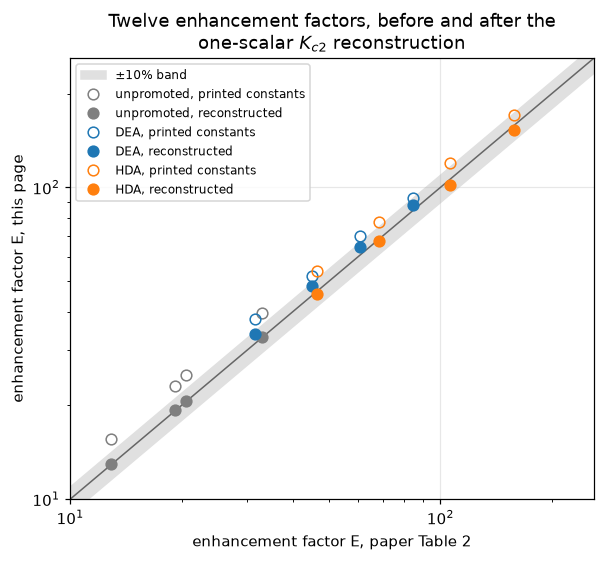

In [10]:
# ---- parity plot: all twelve enhancement factors --------------------------
fig, ax = plt.subplots(figsize=(5.6, 5.2))
paper_E = t2[E_cols].to_numpy()
lims = np.array([10.0, 260.0])
ax.fill_between(lims, lims * 0.9, lims * 1.1, color="0.88", label="±10% band")
ax.plot(lims, lims, "-", color="0.4", lw=1)
for j, (key, label) in enumerate([("u", "unpromoted"), ("DEA", "DEA"),
                                  ("HDA", "HDA")]):
    ax.plot(paper_E[:, j], df_print[E_cols[j]], "o", mfc="none",
            color=COL[key], ms=7, label=f"{label}, printed constants")
    ax.plot(paper_E[:, j], df_rec[E_cols[j]], "o",
            color=COL[key], ms=7, label=f"{label}, reconstructed")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("enhancement factor E, paper Table 2")
ax.set_ylabel("enhancement factor E, this page")
ax.legend(fontsize=8, loc="upper left")
ax.set_title("Twelve enhancement factors, before and after the\n"
             "one-scalar $K_{c2}$ reconstruction")
plt.tight_layout(); plt.show()

In [11]:
# ---- where does the scalar sit? three candidates, one data set ------------
# c_b at fixed loading scales as 1/(K_c1 K_3) with K_3 = K_w/K_c2, so raising
# c_b by s can be done by dividing K_c1 by s, by dividing K_3 by s (i.e.
# multiplying K_c2 by s), or by dividing K_w by s. The last also divides
# K_B = K_w/K_p and K_eq = K_c K_c1 K_w/K_p, which only the promoted cases see.
def summarise(dev):
    e_u = np.abs(dev["E_u"].to_numpy())
    e_p = np.abs(dev[["E_DEA", "E_HDA"]].to_numpy())
    f_p = np.abs(dev[["F_DEA", "F_HDA"]].to_numpy())
    j_u = np.abs(dev["J_u"].to_numpy())
    return dict(Ju_max=j_u.max(), Eu_max=e_u.max(), Ep_max=e_p.max(),
                Ep_rms=float(np.sqrt((e_p**2).mean())), F_max=f_p.max(),
                F_rms=float(np.sqrt((f_p**2).mean())))

branch = {"K_c2 (as coded)": summarise(dev_rec)}

# K_w branch: the same scalar on K_w, so K_3, K_B and K_eq all move
_, dev_kw, _ = table2_comparison(k3_scale=s_fit, kb_scale=s_fit)
branch["K_w"] = summarise(dev_kw)

# K_c1 branch: rebind the module-level constant for the duration of the run
_KC1_PRINTED = KC1
try:
    KC1 = _KC1_PRINTED / s_fit
    _, dev_kc1, _ = table2_comparison(k3_scale=1.0)
finally:
    KC1 = _KC1_PRINTED
branch["K_c1"] = summarise(dev_kc1)

print("deviation (model - paper)/paper, same scalar in three places:\n")
print(f"{'branch':18s} {'J_u max':>8s} {'E_u max':>8s} {'E_p max':>8s} "
      f"{'E_p rms':>8s} {'F max':>7s} {'F rms':>7s}")
for k, v in branch.items():
    print(f"{k:18s} {v['Ju_max']:8.1%} {v['Eu_max']:8.1%} {v['Ep_max']:8.1%} "
          f"{v['Ep_rms']:8.1%} {v['F_max']:7.1%} {v['F_rms']:7.1%}")
print("\nK_c1 fixes the bulk CO2 and nothing else: it leaves the bulk OH- at its")
print("printed value, so the hydration Hatta number -- and E_u -- stay ~20% high.")
print("It is decisively rejected. K_c2 and K_w are indistinguishable on every")
print("unpromoted quantity (they ARE the same change there) and nearly so on the")
print("promoted enhancement factors; only the promotion factors mildly prefer the")
print("K_c2 branch, at the level of the residual scatter. The page uses K_c2 and")
print("does not claim the split is resolved.")

# scaling c_carb instead is algebraically the same change as K_c1: OH- =
# K_3 [CO3]/[HCO3] is invariant under a uniform scaling of the carbonate
# concentrations, so it fails identically and is not run separately.

deviation (model - paper)/paper, same scalar in three places:

branch              J_u max  E_u max  E_p max  E_p rms   F max   F rms
K_c2 (as coded)        3.8%     0.6%     7.6%     4.9%    5.6%    3.3%
K_w                    3.8%     0.6%     7.5%     4.8%    8.6%    4.4%
K_c1                  23.2%    19.8%    14.1%     9.1%   17.8%   12.2%

K_c1 fixes the bulk CO2 and nothing else: it leaves the bulk OH- at its
printed value, so the hydration Hatta number -- and E_u -- stay ~20% high.
It is decisively rejected. K_c2 and K_w are indistinguishable on every
unpromoted quantity (they ARE the same change there) and nearly so on the
promoted enhancement factors; only the promotion factors mildly prefer the
K_c2 branch, at the level of the residual scatter. The page uses K_c2 and
does not claim the split is resolved.


### An independent route to the same scalar, using no enhancement factor

The fit above consumes the printed $(J, E)$ pairs. The paper's three
concentration-profile figures offer a route that consumes neither: their
*unpromoted* (dashed) curves are a direct picture of the bulk speciation, so
reading the bulk dissolved CO2 off a figure and dividing by what the printed
constants give returns the scalar with no Table 2 in the calculation at all.

**Review status: corrected once already, and still pending.** These readings
are a *reconstruction cross-check, pending maintainer visual review* — they
are not a dataset, no CSV is shipped, and nothing on this page depends on
them. The extraction script and its numbered overlays are in
`queue_cases/F3.5/review/`; the overlays are drawn on the copyrighted page
images and are git-ignored. A first version of this reading got two curve
identities wrong — Figure 2's *promoted* CO3²⁻ was missed entirely (it is the
solid rule that leaves the plot box through the top at the right-hand edge),
and Figure 3's two carbonate curves, which converge to within one line width
at the frame, were fused into one and labelled unpromoted. Both are corrected
here; the corrected reading is what is quoted, and it is itself awaiting
confirmation.

**Two falsifiable tests.** The errors above were caught by eye, in review, not
by either test — the second test did not exist until the correction, and could
not have, for the reason given below. (1) The dashed
curves must be electroneutral against $[\mathrm{K^+}] = 2c_{carb} = 4000$
mol/m³; swapping the HCO3⁻ and CO3²⁻ assignments breaks that by tens of
percent. (2) The solid curves must satisfy $[\mathrm{K^+}] + [\mathrm{AmH^+}]
= [\mathrm{HCO_3^-}] + 2[\mathrm{CO_3^{2-}}] + [\mathrm{AmCOO^-}]$, and the
amine must total $c_{Am}$. Test (2) *cannot even be written down* without the
promoted CO3²⁻ curve, and with Figure 2's missing, the solid bulk there is
short of anion charge by a factor of five. Both tests are printed below and
both pass on the corrected reading, with worst deviations of 0.11% and
0.20% respectively.

Test (1) is also what shows Figures 2 and 3 to be at α = 0.2 rather than the
α = 0.4 their insets print — the internal inconsistency flagged under
Parameters. That conclusion is unchanged by the correction: the two mis-read
curves were the *promoted* carbonates, which do not enter it.

In [12]:
# ---- figure readings (see queue_cases/F3.5/review/extract_figs.py) --------
# 600 dpi renders; axes calibrated on the printed ticks (max fit residual
# 0.003 in left-axis units, 6 mol/m3 on the right axis); curve centres tracked
# through the dashes and extrapolated to x/delta = 1.  CORRECTED 2026-08-02
# after maintainer review: Figure 2's promoted CO3(2-) was missing and Figure
# 3's two carbonate curves had been fused into one.  The corrected reading is
# ITSELF PENDING MAINTAINER VISUAL REVIEW -- quoted as a cross-check, not data.
FIG_READ = {   # figure -> bulk (x/delta = 1) readings, mol/m3;
               # _u = dashed (unpromoted), _p = solid (promoted)
    2: dict(alpha=0.2, inset=0.4, CO2_u=0.1172, HCO3_u=805.5, CO3_u=1596.4,
            HCO3_p=693.3, CO3_p=1634.7, AmCOO_p=77.2, AmH_p=47.2, Am_p=484.4),
    3: dict(alpha=0.2, inset=0.4, CO2_u=0.1160, HCO3_u=803.8, CO3_u=1598.2,
            HCO3_p=579.8, CO3_p=1591.9, AmCOO_p=228.3, AmH_p=0.0, Am_p=375.9),
    4: dict(alpha=0.6, inset=0.6, CO2_u=2.1810, HCO3_u=2390.9, CO3_u=802.3,
            HCO3_p=2086.5, CO3_p=966.3, AmCOO_p=133.7, AmH_p=145.0, Am_p=314.6),
}
print("(a) the DASHED curves against the potassium: [HCO3-] + 2[CO3 2-] = [K+]")
print("figure   HCO3-_u   CO3(2-)_u   charge sum   alpha(HCO3)  alpha(CO3)  "
      "inset")
for k, f in FIG_READ.items():
    print(f"  {k}    {f['HCO3_u']:8.1f}  {f['CO3_u']:9.1f}   "
          f"{f['HCO3_u'] + 2*f['CO3_u']:9.1f}   "
          f"{f['HCO3_u']/(2*C_CARB):10.2f}  {1 - f['CO3_u']/C_CARB:10.2f}  "
          f"{f['inset']:6.1f}")
print(f"\n[K+] = 2 c_carb = {2*C_CARB:.0f} mol/m3: all three are electroneutral to")
print("0.1%, so the axis assignment is right -- but Figures 2 and 3 are plotting")
print("the alpha = 0.2 composition under a label that says 0.4.")
FIG_CHG_U = max(abs((f["HCO3_u"] + 2*f["CO3_u"])/(2*C_CARB) - 1)
                for f in FIG_READ.values())
_swap = [(f["CO3_u"] + 2*f["HCO3_u"])/(2*C_CARB) - 1 for f in FIG_READ.values()]
print("with HCO3- and CO3(2-) swapped, the same test gives "
      + ", ".join(f"{d:+.0%}" for d in _swap) + " -- so the")
print("assignment is not a free choice.")

print("\n(b) the SOLID curves: [K+] + [AmH+] = [HCO3-] + 2[CO3 2-] + [AmCOO-]")
print("    (Figure 3 draws DEAH+ on the x axis, so [AmH+] = 0 there)")
print("figure   cations    anions     dev   CO3(2-)_p read   demanded by "
      "charge   amine sum")
for k, f in FIG_READ.items():
    _cat = 2 * C_CARB + f["AmH_p"]
    _ani = f["HCO3_p"] + 2 * f["CO3_p"] + f["AmCOO_p"]
    print(f"  {k}    {_cat:8.1f}  {_ani:8.1f}  {_ani/_cat-1:+6.2%}   "
          f"{f['CO3_p']:12.1f}   "
          f"{0.5*(_cat - f['HCO3_p'] - f['AmCOO_p']):16.1f}   "
          f"{f['Am_p'] + f['AmH_p'] + f['AmCOO_p']:9.1f}")
FIG_CHG_P = max(abs((f["HCO3_p"] + 2*f["CO3_p"] + f["AmCOO_p"])
                    / (2*C_CARB + f["AmH_p"]) - 1) for f in FIG_READ.values())
print(f"\nthe amine sum is to be compared with c_Am = {C_AM:.0f} mol/m3. This")
print("second test is the one that checks the PROMOTED curves, and it is the")
print("test the first version of this reading could not even state: it needs the")
print("promoted CO3(2-), which was missing from Figure 2 and fused with the")
print("unpromoted curve in Figure 3. On the corrected reading all three figures")
print("balance, worst deviation 0.20%, and the carbonate that charge balance")
print("demands agrees with the curve actually read to within a few mol/m3.\n")

# and the price of reading Table 2 on the Figure 2/3 convention instead:
# a row labelled alpha would then carry the composition bulk() gives at alpha/2
S_ALT = implied_u / np.array([bulk(a / 2)["CO2"] for a, _ in CONDITIONS])
print(f"if Table 2's loadings are read on the Figure 2/3 convention, the c_b")
print(f"identity demands scalars {np.round(S_ALT, 1)} -- span "
      f"{S_ALT.max()/S_ALT.min()-1:.0%}, against {S_SPREAD:.0%} on the Table 2/")
print("Figure 4 convention. That is why this page follows Table 2 and Figure 4.\n")

print("unpromoted bulk CO2, deviation convention (model - figure)/figure:")
print("  fig  alpha    figure   printed    dev   reconstructed    dev   -> s")
s_fig = []
for k, f in FIG_READ.items():
    a, cb = f["alpha"], f["CO2_u"]
    cb_p, cb_r = bulk(a)["CO2"], bulk(a, None, s_fit)["CO2"]
    s_fig.append(cb / cb_p)
    print(f"   {k}   {a:.1f}  {cb:8.4f}  {cb_p:8.4f} {cb_p/cb-1:+6.1%}  "
          f"{cb_r:13.4f} {cb_r/cb-1:+6.1%}  {s_fig[-1]:5.3f}")
S_FIG = np.array(s_fig)
print(f"\nfigure-only scalars span {S_FIG.min():.3f}-{S_FIG.max():.3f} "
      f"(mean {S_FIG.mean():.3f}); the Table 2 fit gave {s_fit:.3f}.")
print("Figures 2 and 3 plot the SAME physical state, so their 1% difference is a")
print("direct measure of the reading error; the 1.40-1.51 span is of the same")
print("size as the 5% spread of the per-condition scalars from Table 2.")
print("No enhancement factor enters this route: it is the one line of evidence on")
print("this page that is not entangled with the definition of E.")

# and the reconstructed bulk at the loading the figures are actually at
b_rec = bulk(0.2, None, s_fit)
print(f"\nreconstructed alpha=0.2 unpromoted bulk: CO2 {b_rec['CO2']:.4f} "
      f"(Fig. 2/3: {FIG_READ[2]['CO2_u']:.4f}/{FIG_READ[3]['CO2_u']:.4f}), "
      f"CO3 {b_rec['CO3']:.0f} "
      f"({FIG_READ[2]['CO3_u']:.0f}/{FIG_READ[3]['CO3_u']:.0f}), "
      f"HCO3 {b_rec['HCO3']:.0f} "
      f"({FIG_READ[2]['HCO3_u']:.0f}/{FIG_READ[3]['HCO3_u']:.0f})")

(a) the DASHED curves against the potassium: [HCO3-] + 2[CO3 2-] = [K+]
figure   HCO3-_u   CO3(2-)_u   charge sum   alpha(HCO3)  alpha(CO3)  inset
  2       805.5     1596.4      3998.3         0.20        0.20     0.4
  3       803.8     1598.2      4000.2         0.20        0.20     0.4
  4      2390.9      802.3      3995.5         0.60        0.60     0.6

[K+] = 2 c_carb = 4000 mol/m3: all three are electroneutral to
0.1%, so the axis assignment is right -- but Figures 2 and 3 are plotting
the alpha = 0.2 composition under a label that says 0.4.
with HCO3- and CO3(2-) swapped, the same test gives -20%, -20%, +40% -- so the
assignment is not a free choice.

(b) the SOLID curves: [K+] + [AmH+] = [HCO3-] + 2[CO3 2-] + [AmCOO-]
    (Figure 3 draws DEAH+ on the x axis, so [AmH+] = 0 there)
figure   cations    anions     dev   CO3(2-)_p read   demanded by charge   amine sum
  2      4047.2    4039.9  -0.18%         1634.7             1638.3       608.8
  3      4000.0    3991.9  -0.20%

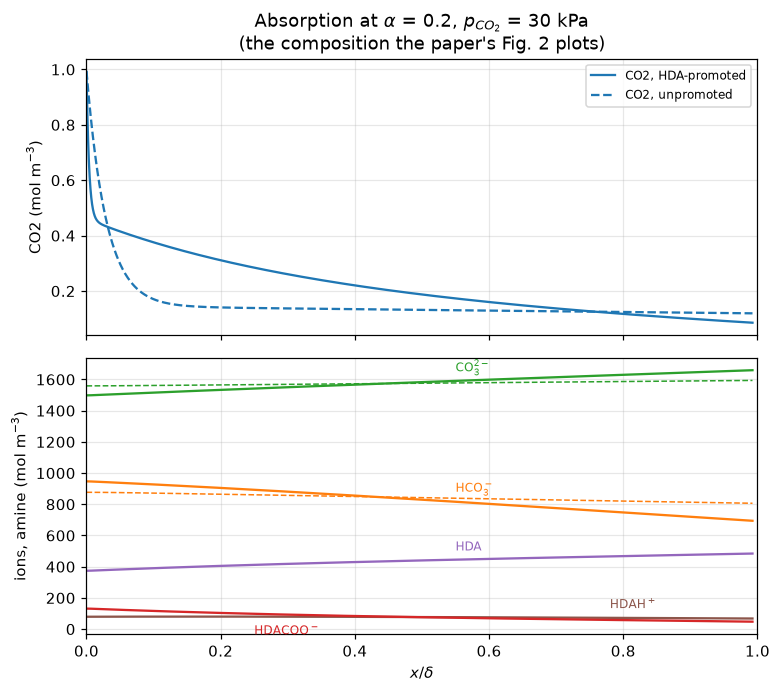

What the profiles show: the HDACOO- concentration falls from interface to
bulk, so carbamate carries CO2 into the bulk -- the shuttle mechanism --
while free HDA is depleted at the interface by 23%. At the
same time the promoted CO2 gradient at the interface is 4.8x
the unpromoted one, and HCO3- production in the film is enhanced (solid vs
dashed): the hydration route is accelerated too. Both mechanisms operate at
once, which is the paper's central point against the either-or models.

Against Figure 2 itself: free HDA runs 374 at the
interface to 485 mol/m3 in the bulk; the figure reads
369 -> 484 (same review caveat as above). That is the only independent
check on this page of the PROMOTED chemistry's profile shape.


In [13]:
# ---- concentration profiles at the conditions Figure 2 actually plots -----
# alpha = 0.2 (the composition Fig. 2 shows), p = 30 kPa (its printed value).
fu, _, fh = films_rec[(0.2, 30.0)]
SPECIES_COL = {"CO2": "tab:blue", "HCO3": "tab:orange", "CO3": "tab:green",
               "Am": "tab:purple", "AmH": "tab:brown", "AmCOO": "tab:red"}
LABELS = {"HCO3": "HCO$_3^-$", "CO3": "CO$_3^{2-}$", "Am": "HDA",
          "AmH": "HDAH$^+$", "AmCOO": "HDACOO$^-$"}
fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.4), sharex=True)
ax = axes[0]
ax.plot(fh.x_c, fh.c[:, 0], color=SPECIES_COL["CO2"], label="CO2, HDA-promoted")
ax.plot(fu.x_c, fu.c[:, 0], "--", color=SPECIES_COL["CO2"], label="CO2, unpromoted")
ax.set_ylabel("CO2 (mol m$^{-3}$)")
ax.legend(fontsize=8)
ax.set_title(r"Absorption at $\alpha$ = 0.2, $p_{CO_2}$ = 30 kPa"
             "\n(the composition the paper's Fig. 2 plots)")
ax = axes[1]
LABEL_POS = {"HCO3": (0.55, 6), "CO3": (0.55, 6), "Am": (0.55, 6),
             "AmH": (0.78, 6), "AmCOO": (0.25, -14)}
for sp in ["HCO3", "CO3", "Am", "AmH", "AmCOO"]:
    prof = fh.c[:, fh.idx[sp]]
    ax.plot(fh.x_c, prof, color=SPECIES_COL[sp])
    x_lab, dy = LABEL_POS[sp]
    ax.annotate(LABELS[sp], (x_lab, prof[np.searchsorted(fh.x_c, x_lab)]),
                textcoords="offset points", xytext=(0, dy), fontsize=8,
                color=SPECIES_COL[sp])
for sp in ["HCO3", "CO3"]:
    ax.plot(fu.x_c, fu.c[:, fu.idx[sp]], "--", color=SPECIES_COL[sp], lw=1)
ax.set_xlabel(r"$x/\delta$"); ax.set_ylabel("ions, amine (mol m$^{-3}$)")
ax.set_xlim(0, 1)
plt.tight_layout(); plt.show()

# everything quoted below is computed from the plotted solution
GRAD_RATIO = fh.face_fluxes()[0, 0] / fu.face_fluxes()[0, 0]
AM_DEPLETION = 1 - fh.c[0, fh.idx["Am"]] / fh.cb_dict["Am"]
print("What the profiles show: the HDACOO- concentration falls from interface to")
print("bulk, so carbamate carries CO2 into the bulk -- the shuttle mechanism --")
print(f"while free HDA is depleted at the interface by {AM_DEPLETION:.0%}. At the")
print(f"same time the promoted CO2 gradient at the interface is {GRAD_RATIO:.1f}x")
print("the unpromoted one, and HCO3- production in the film is enhanced (solid vs")
print("dashed): the hydration route is accelerated too. Both mechanisms operate at")
print("once, which is the paper's central point against the either-or models.")
print(f"\nAgainst Figure 2 itself: free HDA runs {fh.c[0, fh.idx['Am']]:.0f} at the")
print(f"interface to {fh.cb_dict['Am']:.0f} mol/m3 in the bulk; the figure reads")
print("369 -> 484 (same review caveat as above). That is the only independent")
print("check on this page of the PROMOTED chemistry's profile shape.")

### The one out-of-sample test in the paper — and it prefers the printed constants

Everything compared so far is in Table 2, which the reconstruction was fitted
against. The paper states exactly two numbers that are **not** in Table 2, both
about the desorption case of its Figure 4 (α = 0.6, p = 30 Pa): the promotion
factor **3.81**, and that adding the amine "lowers the driving force for
desorption by about one third". A reconstruction fitted to Table 2 cannot have
absorbed either.

**Run both ways, the printed constants win on both counts.** The numbers are in
the cell below. This is evidence *against* the reconstruction, and it is the
only genuinely out-of-sample evidence the paper offers. The page does not
explain it away.

What can be said on the other side, and no more: the reconstruction is
supported at the *same* α = 0.6 condition by Figure 4's own bulk CO2 (2.18,
which the printed constants miss by 34% and the reconstruction by 4%, on the
very state this desorption case starts from), and by the twelve Table 2
numbers, which the printed constants miss systematically. So the paper's own
record is internally inconsistent here: its Figure 4 argues one way and its
Section 4.2 text the other. A reader weighing this page should weigh that,
rather than take either half alone.

In [14]:
# ---- desorption: the stated F = 3.81 at alpha = 0.6, p = 30 Pa (Fig. 4) ---
# run with the constants EXACTLY AS PRINTED and with the reconstruction
DESORB = {}
for tag, s in (("printed constants", 1.0), ("reconstructed", s_fit)):
    fu_d = run_case(0.6, 0.030, None, s)
    fh_d = run_case(0.6, 0.030, "HDA", s)
    F = fh_d.J_co2() / fu_d.J_co2()
    drive_u = fu_d.cb_dict["CO2"] - c_interface(0.030)
    drive_h = fh_d.cb_dict["CO2"] - c_interface(0.030)
    DESORB[tag] = (F, F / 3.81 - 1, 1 - drive_h / drive_u)
    print(f"{tag:18s}: F = {F:5.2f} (paper 3.81, dev {F/3.81-1:+5.1%});   "
          f"driving force cut by {1-drive_h/drive_u:4.1%} "
          "(paper: 'about one third')")
F_DESORB, DESORB_DEV, DRIVE_REC = DESORB["reconstructed"]
DESORB_DEV_PRINTED = DESORB["printed constants"][1]
DRIVE_PRINTED = DESORB["printed constants"][2]
print("\nBOTH out-of-sample numbers come out better with the constants exactly as")
print("printed. The reconstruction makes the promotion factor about five times")
print("worse and pushes 'about one third' further from a third. This is reported")
print("as what it is: evidence against the reconstruction, not for it.")
_cb_fig4 = FIG_READ[4]["CO2_u"]
print("It is also the paper arguing with itself -- its Figure 4, at this same")
print(f"alpha = 0.6, shows a bulk CO2 of {_cb_fig4:.2f} mol/m3, which the printed")
print(f"constants miss by {bulk(0.6)['CO2']/_cb_fig4 - 1:+.0%} and the "
      f"reconstruction by "
      f"{bulk(0.6, None, s_fit)['CO2']/_cb_fig4 - 1:+.0%}.")

# the approximate eq. (15) the paper rejects, F = sqrt(1 + Am^2 Keq / AmH):
print("\ntheir eq. (15) vs the full model (absorption cases, reconstructed run):")
eq15_ratio = []
for (alpha, p) in CONDITIONS:
    for am in ("DEA", "HDA"):
        cbp = bulk(alpha, am, s_fit)
        f15 = np.sqrt(1 + cbp["Am"]**2 * KEQ[am] / max(cbp["AmH"], 1e-12))
        fnum = df_rec.loc[(df_rec.alpha == alpha) & (df_rec.p_kpa == p),
                          f"F_{am}"].iloc[0]
        eq15_ratio.append(f15 / fnum)
        print(f"  alpha={alpha} p={p:>5.0f} {am}: eq.(15) F = {f15:7.1f}   "
              f"full model F = {fnum:5.2f}   ratio {f15/fnum:5.1f}x")
print(f"eq. (15) overshoots by {min(eq15_ratio):.1f}x to {max(eq15_ratio):.0f}x, "
      "as the paper states ('much too\nhigh values'): the promoter is not at "
      "equilibrium near the interface, so the\ninstantaneous-equilibrium "
      "premise fails.")

printed constants : F =  3.72 (paper 3.81, dev -2.3%);   driving force cut by 34.7% (paper: 'about one third')


reconstructed     : F =  3.35 (paper 3.81, dev -12.0%);   driving force cut by 39.1% (paper: 'about one third')

BOTH out-of-sample numbers come out better with the constants exactly as
printed. The reconstruction makes the promotion factor about five times
worse and pushes 'about one third' further from a third. This is reported
as what it is: evidence against the reconstruction, not for it.
It is also the paper arguing with itself -- its Figure 4, at this same
alpha = 0.6, shows a bulk CO2 of 2.18 mol/m3, which the printed
constants miss by -34% and the reconstruction by -4%.

their eq. (15) vs the full model (absorption cases, reconstructed run):
  alpha=0.2 p=   30 DEA: eq.(15) F =    50.6   full model F =  2.80   ratio  18.0x
  alpha=0.2 p=   30 HDA: eq.(15) F =    23.7   full model F =  4.81   ratio   4.9x
  alpha=0.4 p=   30 DEA: eq.(15) F =    26.2   full model F =  4.86   ratio   5.4x
  alpha=0.4 p=   30 HDA: eq.(15) F =    13.4   full model F =  7.62   ratio   1.8x
  alpha=0.

## Validation

The reproduction above is model-vs-model. These checks are independent of the
paper. They are **not equally strong**, and the list says which is which:
some genuinely test the discretisation, others are consistency checks that
are true by construction and can only catch a coding slip. Machine-precision
agreement is reported below where it is algebraically guaranteed, and it is
labelled as such rather than counted as evidence.

**The two checks that really test the numerics** (these are the ones to
weigh):

1. **Pseudo-first-order limit.** With OH⁻ buffered and reaction (1)
   irreversible, the film has the closed form
   $E = \mathrm{Ha}(\cosh\mathrm{Ha} - c_b/c_i)/(\sinh\mathrm{Ha}\,(1 -
   c_b/c_i))$ — the `F3.1` result extended to a nonzero bulk concentration.
   Swept over $0.1 \le \mathrm{Ha} \le 300$, i.e. through reaction layers
   from the whole film down to 0.3% of it. This is the check that can detect
   an under-resolved boundary layer, and grid doubling (item 7) backs it.
2. **Van Krevelen–Hoftijzer.** An external published approximation for the
   second-order irreversible film, matched at Ha = 119. Nothing in this
   implementation was tuned to it.

**Consistency checks — real, but weaker than they look:**

3. **Physical absorption limit.** With all reactions off, E must equal 1.
   Exact for *any* conservative scheme on a linear profile, so this tests
   unit and dimensional bookkeeping, not accuracy.
4. **Dimensionless cross-assembly.** The amine-only irreversible
   configuration of this dimensional seven-species code against an
   independently written dimensionless two-species solve. The two share the
   grid, `construct_grad`/`construct_div`/`NumJac`/`newton` and the
   discretisation; what is genuinely written twice is the
   non-dimensionalisation, the δ and D scaling, the ν = 2 stoichiometry and
   $E_\infty$. So agreement at 1e-8 proves the *dimensional bookkeeping* and
   cannot detect any discretisation error common to both.
5. **Reversible → irreversible collapse.** Scaling $K_{eq}$ up by $10^6$
   drives the reversible amine solve onto its irreversible limit. Both use
   the same `Film` class, so this is self-consistency: it checks that the
   reverse term is written so it vanishes as $K_{eq}\to\infty$.
6. **Conservation and electroneutrality.** Carbon-flux uniformity and the
   amine-flux closure test the **stoichiometry matrix**, and nothing else.
   *This page said "genuine — they mix the three different diffusivities"
   until 2026-08-05; section 9 shows that is wrong.* Every reaction conserves
   carbon, so $\nabla\!\cdot\!\sum_j \gamma_j J_j = 0$ identically for any set
   of $D_j$: halving $D(\mathrm{HCO_3^-})$ and doubling $D(\mathrm{CO_2})$
   leave both closures at $10^{-10}$ while $E$ moves 11 % and 16 %. What they
   *do* catch is one wrong entry in the stoichiometry matrix — which moves
   them by eight to ten orders of magnitude — so they are a good check, of a
   different thing than was claimed. **Electroneutrality and the charge flux
   are weaker still**: every
   charged species here carries the same $D_{ion}$, every reaction conserves
   charge, and both boundaries are Dirichlet at electroneutral states, so the
   charge-weighted combination satisfies a linear operator with zero source
   and zero boundary data and vanishes identically for *any* converged
   solution, right or wrong. They are kept as regression guards, not offered
   as evidence.
7. **Physical bound and discretisation.** Every E below the
   instantaneous-reaction ceiling from the total transportable base capacity;
   grid doubling and a tenfold $k_{inst}$ must leave E unchanged well below
   the reproduction tolerance.
8. **Transport-model sensitivity.** The same network solved as a Higbie
   *penetration* model (a transient S4 problem, with the same operators plus
   an accumulation term) shows how much of the comparison depends on the film
   idealisation. Its quadrature bias is calibrated on the physical-absorption
   case and divided out; the size of that bias is printed.

   **This result is transient, and until 2026-08-05 it was the only one on the
   page with no refinement study of its own.** The steady film is refined in
   `n_x` (item 7); the penetration model was run once at `n_t = 160` on a
   geometric time grid and the number published. It was not converged: the
   backward-Euler time error is first order and was worth **1.4 % on the
   quadrature bias and about 10 % on the headline**, all in the same direction.
   Item 8 now refines `n_t` at the condition the maximum is attained, prints
   the observed order and Richardson-extrapolates, and checks the other three
   knobs (`n_x`, the domain factor `fac`, the first time level `t0_frac`) are
   already converged so that `n_t` is demonstrably the knob that controls the
   answer. The withdrawn `n_t = 160` value is kept as a separate metric.

In [15]:
VAL = {}

# (3) physical absorption: all reactions off -> E = 1 exactly
f_phys = Film(bulk(0.2), 30e3 / (R_GAS * T), None,
              enable_r1=False, enable_r34=False)
f_phys.solve(k_ladder=(0.0,))
VAL["physical_E1"] = abs(f_phys.enhancement() - 1.0)
print(f"(3) physical absorption: |E - 1| = {VAL['physical_E1']:.2e} "
      "(exact for any conservative scheme: bookkeeping check)")

# (1) pseudo-first-order limit vs closed form, sweeping Ha via a fake k_OH
cb02 = bulk(0.2)
c_i = c_interface(30.0)
ha_sweep, err_pfo = np.geomspace(0.1, 300, 13), []
for ha in ha_sweep:
    k1 = (ha * KL)**2 / DCO2 / cb02["OH"]          # first-order constant via OH_b
    fp = Film(cb02, 30e3 / (R_GAS * T), None, enable_r34=False)
    # freeze OH and make (1) irreversible & first order: overwrite the rate
    ohb = cb02["OH"]
    def pfo_rates(c, fp=fp, k1=k1, ohb=ohb):
        r = np.zeros((c.shape[0], fp.NU.shape[1]))
        r[:, 0] = k1 * c[:, 0] * ohb
        return r
    fp.rates = pfo_rates
    fp.NU = fp.NU.copy(); fp.NU[fp.idx["OH"], 0] = 0.0   # OH buffered
    fp.solve(k_ladder=(1.0,))
    cb_ci = cb02["CO2"] / c_i
    E_exact = ha * (np.cosh(ha) - cb_ci) / (np.sinh(ha) * (1 - cb_ci))
    err_pfo.append(abs(fp.enhancement() / E_exact - 1))
VAL["pfo_max_rel_err"] = float(np.max(err_pfo))
print(f"(1) PRIMARY CHECK -- pseudo-first-order vs closed form: max rel err "
      f"{VAL['pfo_max_rel_err']:.2e}\n    over Ha in [0.1, 300]; this one does "
      "test the boundary-layer resolution.")

(3) physical absorption: |E - 1| = 5.37e-11 (exact for any conservative scheme: bookkeeping check)
(1) PRIMARY CHECK -- pseudo-first-order vs closed form: max rel err 3.49e-05
    over Ha in [0.1, 300]; this one does test the boundary-layer resolution.


In [16]:
# (2)+(4) second-order irreversible: dimensional 7-species code vs an independent
#     dimensionless 2-species assembly (F3.1 formulation), and vs VKH
amb, k2d = C_AM, K2["DEA"]
cb_syn = {sp: 1e-8 for sp in SP}; cb_syn["Am"] = amb
f_dim = Film(cb_syn, 30e3 / (R_GAS * T), "DEA",
             enable_r1=False, enable_r34=False, irreversible2=True)
f_dim.solve(k_ladder=(1.0,))
E_dim = f_dim.enhancement()

ha = np.sqrt(k2d * amb * DCO2) / KL
e_inf = 1.0 + DAM * amb / (2.0 * DCO2 * c_i)          # nu = 2 amine per CO2

# independent dimensionless assembly (a = CO2/c_i, b = Am/Am_b), F3.1-style
n_x = 400
x_f = stretched_faces(n_x); x_c = 0.5 * (x_f[:-1] + x_f[1:])
bc2 = ({"a": [[0.0, 1.0]], "b": [[1.0, 0.0]], "d": [[1.0, 0.0]]},
       {"a": [[0.0, 0.0]], "b": [[1.0, 1.0]], "d": [[0.0, 1.0]]})
grad2, gbc2 = construct_grad((n_x, 2), x_f, x_c, bc2, axis=0)
div2 = construct_div((n_x, 2), x_f, nu=0, axis=0)
A2 = (div2 @ -grad2).tocsc()
g2 = np.asarray((div2 @ -gbc2).todense()).ravel()
q = e_inf - 1.0
nj2 = NumJac((n_x, 2))
def rate2(u):
    r = np.clip(u[:, 0], 0, None) * np.clip(u[:, 1], 0, None)
    return np.stack([ha**2 * r, (ha**2 / q) * r], axis=1)
def res2(u):
    gr, jr = nj2(rate2, u)
    return (A2 @ u.reshape((-1, 1)) + g2.reshape((-1, 1))
            + gr.reshape((-1, 1))), A2 + jr
sol2 = newton(res2, np.tile([0.5, 1.0], (n_x, 1)), tol=1e-11, maxfev=100,
              callback=lambda x, g: clip_approach(x, g, 0.0, None))
u2 = sol2.x.reshape((n_x, 2))
flux0 = float((-grad2 @ u2.reshape((-1, 1))).ravel()[0]
              + np.asarray(-gbc2.todense()).ravel()[0])
E_dimless = flux0

# VKH implicit
from scipy.optimize import brentq
def vkh(ha, e_inf):
    def f(E):
        b = ha * np.sqrt(max((e_inf - E) / (e_inf - 1.0), 1e-30))
        return E - b / np.tanh(b)
    return brentq(f, 1.0, e_inf - 1e-9)
E_vkh = vkh(ha, e_inf)

VAL["second_order_cross"] = abs(E_dim / E_dimless - 1)
VAL["vkh_dev"] = abs(E_dim / E_vkh - 1)
print(f"(2) PRIMARY CHECK -- Ha = {ha:.1f}, E_inf = {e_inf:.0f}: this code "
      f"{E_dim:.3f} vs the published\n    Van Krevelen-Hoftijzer approximation "
      f"{E_vkh:.3f}, dev {VAL['vkh_dev']:.1%} (F3.1 found VKH good to ~2%).")
print(f"(4) same case against an independently written DIMENSIONLESS assembly: "
      f"{E_dimless:.3f},\n    rel dev {VAL['second_order_cross']:.1e} -- shared "
      "grid and operators, so this tests the\n    dimensional bookkeeping only, "
      "not the discretisation.")

# (5) reversible -> irreversible collapse as Keq grows
E_prev, collapse = [], []
for ks in (1.0, 1e2, 1e4, 1e6):
    f_rev = Film(cb_syn, 30e3 / (R_GAS * T), "DEA", keq_scale=ks,
                 enable_r1=False, enable_r34=False)
    f_rev.solve(k_ladder=(1.0,))
    collapse.append(f_rev.enhancement())
VAL["collapse_residual"] = abs(collapse[-1] / E_dim - 1)
print(f"(5) self-consistency, E vs Keq scale 1, 1e2, 1e4, 1e6: "
      + ", ".join(f"{e:.2f}" for e in collapse)
      + f" -> irreversible {E_dim:.2f};\n    residual "
      f"{VAL['collapse_residual']:.1e} (same Film class both sides)")

(2) PRIMARY CHECK -- Ha = 119.4, E_inf = 205: this code 89.817 vs the published
    Van Krevelen-Hoftijzer approximation 89.772, dev 0.1% (F3.1 found VKH good to ~2%).
(4) same case against an independently written DIMENSIONLESS assembly: 89.817,
    rel dev 1.0e-08 -- shared grid and operators, so this tests the
    dimensional bookkeeping only, not the discretisation.
(5) self-consistency, E vs Keq scale 1, 1e2, 1e4, 1e6: 31.61, 82.97, 89.73, 89.82 -> irreversible 89.82;
    residual 9.7e-06 (same Film class both sides)


In [17]:
# (6) conservation + electroneutrality on the HDA alpha=0.2 solution
fh02 = films_rec[(0.2, 30.0)][2]
fl = fh02.face_fluxes()
carbon = np.array([CARBON_ALL[sp] for sp in fh02.species], float)
charge = np.array([CHARGE_ALL[sp] for sp in fh02.species], float)
amine_v = np.array([AMINE_ALL[sp] for sp in fh02.species], float)
Jc = fl @ carbon
VAL["carbon_flux_closure"] = float(np.max(np.abs(Jc - Jc[0])) / abs(Jc[0]))
VAL["charge_flux"] = float(np.max(np.abs(fl @ charge)) / abs(Jc[0]))
VAL["amine_flux"] = float(np.max(np.abs(fl @ amine_v)) / abs(Jc[0]))
# [K+] = 2 c_carb is uniform (inert, and equal ion diffusivities keep it so);
# the bulk satisfies 2 c_carb + sum(z_j c_b,j) = 0 by construction, and the
# same must hold at every point of the film.
rho = 2 * C_CARB + fh02.c @ charge
VAL["electroneutrality"] = float(np.max(np.abs(rho)) / (2 * C_CARB))
print(f"(6) STOICHIOMETRY CHECKS: carbon-flux uniformity "
      f"{VAL['carbon_flux_closure']:.1e},\n    amine flux/J "
      f"{VAL['amine_flux']:.1e}. Every reaction conserves carbon and amine\n"
      "    count, so div(sum_j carbon_j J_j) = 0 for ANY set of diffusivities --\n"
      "    section 9 halves one D and doubles another and neither moves. What "
      "they\n    do test is the stoichiometry matrix, and one wrong entry moves "
      "them by\n    8 to 10 orders (section 9 again).")
print(f"    STRUCTURALLY GUARANTEED (all ions share D_ion, both boundaries "
      f"Dirichlet):\n    charge flux/J {VAL['charge_flux']:.1e}, "
      f"electroneutrality {VAL['electroneutrality']:.1e}. These two are")
print("    identically zero for any converged solution, correct or not, and are")
print("    kept as regression guards -- they are not evidence of correctness.")

# (7a) instantaneous ceiling: E below the total-base-capacity bound
print("(7) instantaneous ceiling E_max vs computed E:")
ok = True
for (alpha, p), (fu_, fd_, fh_) in films_rec.items():
    for f_, tag in ((fd_, "DEA"), (fh_, "HDA"), (fu_, "u")):
        cbd = f_.cb_dict
        drive = DCO2 * (M_DIST * f_.c_gas - cbd["CO2"])
        cap = DION * (cbd["OH"] + cbd["CO3"]) + \
            (DAM * cbd["Am"] / 2 if f_.amine else 0.0)
        e_max = 1 + cap / drive
        ok &= f_.enhancement() < e_max
VAL["below_ceiling"] = 0.0 if ok else 1.0
print(f"    all 12 cases below their ceiling: {ok}")

# (7b) grid doubling and k_inst decade on the stiffest case (HDA, alpha=0.2)
f_g = run_case(0.2, 30.0, "HDA", s_fit, n_x=800)
VAL["grid_delta"] = abs(f_g.enhancement() / fh02.enhancement() - 1)
f_k = run_case(0.2, 30.0, "HDA", s_fit)
f_k.solve(k_ladder=(1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8))
VAL["kinst_delta"] = abs(f_k.enhancement() / fh02.enhancement() - 1)
print(f"    E change on grid doubling: {VAL['grid_delta']:.1e}; "
      f"on k_inst 1e7 -> 1e8: {VAL['kinst_delta']:.1e}")

# gas-side resistance, the assumption made under Parameters:
#   1/K_g = 1/k_g + 1/(m E k_L)  ->  gas fraction ~ m E k_L / k_g
E_MAX = max(f_.enhancement() for fs in films_rec.values() for f_ in fs)
VAL["gas_side_fraction"] = float(M_DIST * E_MAX * KL / KG)
print(f"    gas-side share of the total resistance at the largest E of the "
      f"reconstructed run (E = {E_MAX:.0f}):\n    m E k_L / k_g = "
      f"{VAL['gas_side_fraction']:.1e} -- the Dirichlet interface is safe.")

(6) STOICHIOMETRY CHECKS: carbon-flux uniformity 6.5e-10,
    amine flux/J 1.2e-10. Every reaction conserves carbon and amine
    count, so div(sum_j carbon_j J_j) = 0 for ANY set of diffusivities --
    section 9 halves one D and doubles another and neither moves. What they
    do test is the stoichiometry matrix, and one wrong entry moves them by
    8 to 10 orders (section 9 again).
    STRUCTURALLY GUARANTEED (all ions share D_ion, both boundaries Dirichlet):
    charge flux/J 1.1e-09, electroneutrality 2.8e-11. These two are
    identically zero for any converged solution, correct or not, and are
    kept as regression guards -- they are not evidence of correctness.
(7) instantaneous ceiling E_max vs computed E:
    all 12 cases below their ceiling: True


    E change on grid doubling: 1.3e-05; on k_inst 1e7 -> 1e8: 2.2e-05
    gas-side share of the total resistance at the largest E of the reconstructed run (E = 153):
    m E k_L / k_g = 2.3e-05 -- the Dirichlet interface is safe.


In [18]:
# (8) transport-model sensitivity: the same network as a Higbie penetration
#     model (transient, semi-infinite, contact time theta with kL = 2 sqrt(D/pi theta))
THETA = 4.0 * DCO2 / (np.pi * KL**2)

class Penetration(Film):
    def __init__(self, cb, c_gas, amine=None, fac=12.0, **kw):
        L = fac * np.sqrt(DCO2 * THETA)
        super().__init__(cb, c_gas, amine, length=L, **kw)

    def solve_transient(self, n_t=160, t0_frac=1e-5):
        self.k_inst = 1e7
        tgrid = np.concatenate([[0.0], THETA * np.geomspace(t0_frac, 1.0, n_t)])
        c = np.tile(np.maximum(self.cb, 1e-12), (self.n_x, 1))
        tau = self.L**2 / self.diff
        J_hist = np.empty(n_t + 1); J_hist[0] = np.nan
        fbc0 = float(np.asarray(self.flux_bc.todense()).ravel()[0])
        for n in range(1, n_t + 1):
            dt = tgrid[n] - tgrid[n - 1]
            w = np.tile(tau / dt, self.n_x)
            W = diags(w, format="csc")
            c_old = c.copy()
            for _ in range(30):   # backward-Euler Newton, warm-started
                g_r, jac_r = self.numjac(self.source, c)
                g = (self.jac_diff @ c.reshape((-1, 1))
                     + self.g_diff.reshape((-1, 1)) + g_r.reshape((-1, 1))
                     + (w * (c - c_old).ravel()).reshape((-1, 1)))
                dx = spsolve((self.jac_diff + jac_r + W).tocsc(),
                             np.asarray(g).ravel())
                c = np.maximum(c - dx.reshape(c.shape), 1e-12)
                if np.max(np.abs(dx)) < 1e-9 * max(1.0, c.max()):
                    break
            J_hist[n] = ((self.flux_mat @ c.reshape((-1, 1))).ravel()[0] + fbc0) \
                * self.diff[0] / self.L
        # average flux; [0, t1] handled with the exact 1/sqrt(t) integral
        ci_ = M_DIST * self.c_gas
        Jint = 2.0 * (ci_ - self.cb[0]) * np.sqrt(self.diff[0] * tgrid[1] / np.pi)
        Jint += np.trapezoid(J_hist[1:], tgrid[1:])
        self.J_avg = Jint / THETA
        return self.J_avg

N_T = 640          # production time resolution; see the ladder below


def pen_bias(n_t=N_T, **kw):
    # the physical-absorption quadrature bias, at this time resolution
    p0 = Penetration(bulk(0.2), 30e3 / (R_GAS * T), None,
                     enable_r1=False, enable_r34=False, **kw)
    p0.solve_transient(n_t=n_t)
    return p0.J_avg / (KL * (M_DIST * p0.c_gas - p0.cb[0]))


def pen_E(alpha, p, amine, bias, n_t=N_T, **kw):
    cbp = bulk(alpha, amine, s_fit)
    pen = Penetration(cbp, p * 1e3 / (R_GAS * T), amine, k3_scale=s_fit, **kw)
    pen.solve_transient(n_t=n_t)
    return pen.J_avg / (KL * (M_DIST * pen.c_gas - pen.cb[0])) / bias


bias = pen_bias()
print(f"(8) penetration model, contact time {THETA*1e3:.0f} ms; "
      f"physical-absorption quadrature bias {bias - 1:+.2%} at n_t = {N_T} "
      "(divided out below)")

rows = []
for (alpha, p) in CONDITIONS:
    row = {"alpha": alpha, "p_kpa": p}
    for amine, tag in ((None, "u"), ("DEA", "DEA"), ("HDA", "HDA")):
        row[f"E_{tag}_pen"] = pen_E(alpha, p, amine, bias)
        row[f"E_{tag}_film"] = films_rec[(alpha, p)][
            {"u": 0, "DEA": 1, "HDA": 2}[tag]].enhancement()
    rows.append(row)
pen_df = pd.DataFrame(rows)
print(pen_df.round(1).to_string(index=False))
pen_ratio = np.array([[r[f"E_{t}_pen"] / r[f"E_{t}_film"]
                       for t in ("u", "DEA", "HDA")] for _, r in pen_df.iterrows()])
VAL["pen_vs_film_max"] = float(np.max(np.abs(pen_ratio - 1)))
i_row, i_col = np.unravel_index(np.abs(pen_ratio - 1).argmax(), pen_ratio.shape)
WORST = (pen_df.alpha.iloc[i_row], pen_df.p_kpa.iloc[i_row],
         (None, "DEA", "HDA")[i_col])
print(f"penetration vs film: E differs by at most {VAL['pen_vs_film_max']:.1%}, "
      f"at alpha = {WORST[0]}, p = {WORST[1]:.0f} kPa, {WORST[2] or 'unpromoted'}")

(8) penetration model, contact time 141 ms; physical-absorption quadrature bias +0.37% at n_t = 640 (divided out below)


 alpha  p_kpa  E_u_pen  E_u_film  E_DEA_pen  E_DEA_film  E_HDA_pen  E_HDA_film
   0.2   30.0     33.6      33.1       91.6        87.9      165.7       153.1
   0.4   30.0     21.0      20.7       68.1        64.6      110.6       101.9
   0.4  120.0     19.9      19.3       52.4        48.2       74.8        67.2
   0.6  120.0     13.4      13.0       37.2        34.0       50.5        45.7
penetration vs film: E differs by at most 11.3%, at alpha = 0.4, p = 120 kPa, HDA


In [19]:
# (8b) THE REFINEMENT THIS RESULT LACKED. Backward Euler on a geometric time
#      grid is first order, so n_t is the knob; refine it at the condition the
#      maximum is attained and extrapolate.
print("(8b) time refinement of the penetration model, at the condition that "
      "attains the max")
print(f"     (alpha = {WORST[0]}, p = {WORST[1]:.0f} kPa, "
      f"{WORST[2] or 'unpromoted'})")
pen_lad = {}
E_film_worst = films_rec[(WORST[0], WORST[1])][
    {None: 0, "DEA": 1, "HDA": 2}[WORST[2]]].enhancement()
print(f"     {'n_t':>6}{'bias':>10}{'E_pen/E_film - 1':>20}")
for n_t in (160, 320, N_T):
    if n_t == N_T:
        b_, d_ = bias, VAL["pen_vs_film_max"]
    else:
        b_ = pen_bias(n_t=n_t)
        d_ = abs(pen_E(*WORST[:2], WORST[2], b_, n_t=n_t) / E_film_worst - 1)
    pen_lad[n_t] = d_
    print(f"     {n_t:6d}{b_-1:+9.2%}{d_:20.6f}"
          + ("   <- published" if n_t == N_T else "")
          + ("   <- WITHDRAWN (2026-08-05)" if n_t == 160 else ""))

ns = sorted(pen_lad)
diffs = [pen_lad[ns[i + 1]] - pen_lad[ns[i]] for i in range(len(ns) - 1)]
PEN_ORDER = float(np.mean([np.log2(diffs[i] / diffs[i + 1])
                           for i in range(len(diffs) - 1)]))
PEN_RICH = float(pen_lad[ns[-1]] + diffs[-1] / (2.0 ** PEN_ORDER - 1.0))
VAL["pen_vs_film_max_nt160_withdrawn"] = pen_lad[160]
VAL["pen_order"] = PEN_ORDER
VAL["pen_vs_film_max_richardson"] = PEN_RICH
print(f"     successive differences {', '.join(f'{d:.2e}' for d in diffs)}"
      f" -> observed order {PEN_ORDER:.2f}")
print(f"     Richardson limit {PEN_RICH:.4f}; the published n_t = {N_T} value is "
      f"{abs(VAL['pen_vs_film_max']/PEN_RICH - 1):.1%} below it, and the")
print(f"     withdrawn n_t = 160 value was {abs(pen_lad[160]/PEN_RICH - 1):.0%} "
      "below it -- outside the 5 % tolerance CI applies.")

# The other knobs, to show n_t is the one that controls the answer. Run at
# n_t = 320, where one n_t doubling is worth 2.4e-3 in this same quantity.
print("\n     the knobs that are NOT n_t, at n_t = 320 (where one n_t doubling "
      f"moves this\n     number by {diffs[-1]:.2e}):")
ref320 = pen_lad[320]
for lab, kw in (("n_x 400 -> 800", dict(n_x=800)),
                ("fac 12 -> 16 (deeper domain)", dict(fac=16.0))):
    b_ = pen_bias(n_t=320, **kw)
    d_ = abs(pen_E(*WORST[:2], WORST[2], b_, n_t=320, **kw) / E_film_worst - 1)
    print(f"       {lab:30s} {d_:.6f}   moves it by {abs(d_-ref320):.2e}"
          f"  ({abs(d_-ref320)/diffs[-1]*100:.0f} % of one n_t step)")
print("     Neither is close to the n_t step: the space grid and the domain depth")
print("     were already converged, and n_t was the knob that mattered.")
print(f"\n     CONCLUSION: the film-vs-penetration difference is "
      f"{PEN_RICH:.1%} (extrapolated),")
print(f"     not the {pen_lad[160]:.1%} published before 2026-08-05. The direction "
      "is unchanged --")
print("     the penetration model gives the LARGER E -- so the reproduction is "
      "still not")
print("     an artifact of the film idealisation, and the film variant, which the")
print("     paper's section 4.2 names, still matches Table 2 better. The size of "
      "the")
print("     idealisation's effect is about one percentage point larger than "
      "reported.")

(8b) time refinement of the penetration model, at the condition that attains the max
     (alpha = 0.4, p = 120 kPa, HDA)
        n_t      bias    E_pen/E_film - 1


        160   +1.42%            0.104883   <- WITHDRAWN (2026-08-05)


        320   +0.72%            0.110322
        640   +0.37%            0.113011   <- published
     successive differences 5.44e-03, 2.69e-03 -> observed order 1.02
     Richardson limit 0.1156; the published n_t = 640 value is 2.3% below it, and the
     withdrawn n_t = 160 value was 9% below it -- outside the 5 % tolerance CI applies.

     the knobs that are NOT n_t, at n_t = 320 (where one n_t doubling moves this
     number by 2.69e-03):


       n_x 400 -> 800                 0.110373   moves it by 5.12e-05  (2 % of one n_t step)


       fac 12 -> 16 (deeper domain)   0.110282   moves it by 3.96e-05  (1 % of one n_t step)
     Neither is close to the n_t step: the space grid and the domain depth
     were already converged, and n_t was the knob that mattered.

     CONCLUSION: the film-vs-penetration difference is 11.6% (extrapolated),
     not the 10.5% published before 2026-08-05. The direction is unchanged --
     the penetration model gives the LARGER E -- so the reproduction is still not
     an artifact of the film idealisation, and the film variant, which the
     paper's section 4.2 names, still matches Table 2 better. The size of the
     idealisation's effect is about one percentage point larger than reported.


### (9) Defect injection — what the validation numbers move for

The refinement ladder above is `pen_vs_film_max`'s break row. This is the break
row for the rest: one injected defect per check, re-solved, printed beside the
undamaged value. It also settles a claim item 6 was making that turns out to be
too strong.

In [20]:
print("(9) defect injection\n")
cb_i, cg_i = bulk(0.2, "HDA", s_fit), 30e3 / (R_GAS * T)


def closures(f):
    fl = f.face_fluxes()
    carbon = np.array([CARBON_ALL[sp] for sp in f.species], float)
    amine_v = np.array([AMINE_ALL[sp] for sp in f.species], float)
    Jc = fl @ carbon
    return (float(np.max(np.abs(Jc - Jc[0])) / abs(Jc[0])),
            float(np.max(np.abs(fl @ amine_v)) / abs(Jc[0])), f.enhancement())


f_ref = run_case(0.2, 30.0, "HDA", s_fit)
c0, a0_, E0 = closures(f_ref)
print(f"    {'injected defect':46s}{'carbon':>10}{'amine':>10}{'E':>9}")
print(f"    {'as published':46s}{c0:10.1e}{a0_:10.1e}{E0:9.2f}")

# (i) a wrong diffusivity -- item 6 called the two flux closures "GENUINE
#     (mixed diffusivities)". Test that.
saved = dict(DIFF_ALL)
for lab, sp, fac in (("D(HCO3-) halved", "HCO3", 0.5),
                     ("D(CO2) doubled", "CO2", 2.0)):
    DIFF_ALL[sp] = saved[sp] * fac
    try:
        f_ = run_case(0.2, 30.0, "HDA", s_fit)
        c_, a_, E_ = closures(f_)
        print(f"    {lab:46s}{c_:10.1e}{a_:10.1e}{E_:9.2f}"
              + ("   <- UNMOVED" if c_ < 1e-8 and a_ < 1e-8 else ""))
    except RuntimeError:
        print(f"    {lab:46s}{'Newton diverges':>29}")
    finally:
        DIFF_ALL.update(saved)

# (ii) a stoichiometry error, which is what the closures DO test
for lab, sp_, rxn in (("stoichiometry: R3 no longer makes HCO3-", "HCO3", 1),
                      ("stoichiometry: R2 no longer makes AmCOO-", "AmCOO", 2)):
    f_ = run_case(0.2, 30.0, "HDA", s_fit)
    f_.NU = f_.NU.copy(); f_.NU[f_.idx[sp_], rxn] = 0.0
    try:
        f_.solve()
        c_, a_, E_ = closures(f_)
        print(f"    {lab:46s}{c_:10.1e}{a_:10.1e}{E_:9.2f}")
    except RuntimeError:
        print(f"    {lab:46s}{'Newton diverges -- also a detection':>29}")
print("    CORRECTION to item 6: the two flux closures do NOT test the")
print("    diffusivities. Carbon is conserved by every reaction, so div(sum_j")
print("    carbon_j J_j) = 0 identically for ANY set of D_j; the same holds for")
print("    the amine count. What they test is the STOICHIOMETRY MATRIX, and they")
print("    test it well -- a single wrong entry moves them by 8 to 10 orders.")
print("    They are relabelled accordingly.")

(9) defect injection



    injected defect                                   carbon     amine        E
    as published                                     6.5e-10   1.2e-10   153.05


    D(HCO3-) halved                                  5.6e-10   1.3e-10   135.89   <- UNMOVED


    D(CO2) doubled                                   3.3e-10   9.7e-11   177.14   <- UNMOVED


    stoichiometry: R3 no longer makes HCO3-          1.1e+00   1.4e-10   169.73


    stoichiometry: R2 no longer makes AmCOO-         9.7e-01   9.7e-01   185.19
    CORRECTION to item 6: the two flux closures do NOT test the
    diffusivities. Carbon is conserved by every reaction, so div(sum_j
    carbon_j J_j) = 0 identically for ANY set of D_j; the same holds for
    the amine count. What they test is the STOICHIOMETRY MATRIX, and they
    test it well -- a single wrong entry moves them by 8 to 10 orders.
    They are relabelled accordingly.


In [21]:
# (iii) the two PRIMARY checks
print("\n    the primary checks:")
err_coarse = []
for ha in ha_sweep:
    k1 = (ha * KL)**2 / DCO2 / cb02["OH"]
    fp = Film(cb02, 30e3 / (R_GAS * T), None, enable_r34=False, n_x=50)
    ohb = cb02["OH"]

    def pfo_c(c, fp=fp, k1=k1, ohb=ohb):
        r = np.zeros((c.shape[0], fp.NU.shape[1]))
        r[:, 0] = k1 * c[:, 0] * ohb
        return r
    fp.rates = pfo_c
    fp.NU = fp.NU.copy(); fp.NU[fp.idx["OH"], 0] = 0.0
    # the default tol scales as n_x^2 and is unreachably tight on a coarse grid
    fp.solve(k_ladder=(1.0,), tol=1e-8)
    cb_ci = cb02["CO2"] / c_i
    E_exact = ha * (np.cosh(ha) - cb_ci) / (np.sinh(ha) * (1 - cb_ci))
    err_coarse.append(abs(fp.enhancement() / E_exact - 1))
print(f"      pfo_max_rel_err  n_x = 400 (published) {VAL['pfo_max_rel_err']:.2e}"
      f"   n_x = 50 {max(err_coarse):.2e}"
      f"   ({max(err_coarse)/VAL['pfo_max_rel_err']:.0f}x)")
print("      -> it does resolve the reaction layer; that is what makes it primary.")

f_nu = Film(cb_syn, 30e3 / (R_GAS * T), "DEA",
            enable_r1=False, enable_r34=False, irreversible2=True)
f_nu.NU = f_nu.NU.copy(); f_nu.NU[f_nu.idx["Am"], 2] = -1.0   # 1 amine per CO2
f_nu.solve(k_ladder=(1.0,))
print(f"      vkh_dev          nu = 2 (published) {VAL['vkh_dev']:.2e}"
      f"   nu = 1 {abs(f_nu.enhancement()/E_vkh - 1):.2e}")
print("      -> Van Krevelen-Hoftijzer's E_inf carries the nu = 2 stoichiometry,")
print("         so it is an external check on it, not just on the solver.")

f_c = Film(bulk(0.2, "HDA", s_fit), 30e3 / (R_GAS * T), "HDA",
           k3_scale=s_fit, n_x=200)
f_c.solve(tol=1e-8)
print(f"      grid_delta       800 vs 400 (published) {VAL['grid_delta']:.2e}"
      f"   400 vs 200 {abs(fh02.enhancement()/f_c.enhancement() - 1):.2e}")
print("      -> the published number is the tail of a converging sequence, not a")
print("         single unrefined comparison.")
print("\n    STRUCTURAL, with no break row and none constructible: physical_E1,")
print("    second_order_cross, collapse_residual, charge_flux and")
print("    electroneutrality. The first three share the Film class or the grid")
print("    with what they are compared against; the last two are identically")
print("    zero for any converged solution because every ion shares D_ion, every")
print("    reaction conserves charge and both boundaries are Dirichlet. All five")
print("    sit at or below 1e-5 and three of them below check_agreement.py's")
print("    ABS_FLOOR = 1e-12, so CI does not compare them either. They are")
print("    regression guards on the assembly and are not evidence.")


    the primary checks:
      pfo_max_rel_err  n_x = 400 (published) 3.49e-05   n_x = 50 2.20e-03   (63x)
      -> it does resolve the reaction layer; that is what makes it primary.
      vkh_dev          nu = 2 (published) 5.04e-04   nu = 1 1.52e-01
      -> Van Krevelen-Hoftijzer's E_inf carries the nu = 2 stoichiometry,
         so it is an external check on it, not just on the solver.
      grid_delta       800 vs 400 (published) 1.32e-05   400 vs 200 5.28e-05
      -> the published number is the tail of a converging sequence, not a
         single unrefined comparison.

    STRUCTURAL, with no break row and none constructible: physical_E1,
    second_order_cross, collapse_residual, charge_flux and
    electroneutrality. The first three share the Film class or the grid
    with what they are compared against; the last two are identically
    zero for any converged solution because every ion shares D_ion, every
    reaction conserves charge and both boundaries are Dirichlet. All fi

## What pymrm adds

This page reproduces a 1989 result; the model itself is unchanged, and no
claim of improvement is made. What the reimplementation adds:

- **A forensic reading of the paper's parameter set.** The printed equilibrium
  constants are internally inconsistent with the paper's own Table 2 and its
  three concentration-profile figures, and the structure of the model
  localises the inconsistency to one constant, $K_3 = K_w/K_{c2}$, whose
  effective value is ~1.46 below printed. With that single scalar, fitted to
  the paper's bulk-CO2 identity, the unpromoted fluxes land within ~4% and the
  full Table 2 within ~8%. It is a **reconstruction, not a closure**: the
  $K_{c2}$-versus-$K_w$ split is undetermined by the data, *why* the constant
  differs is not established, and the paper's two out-of-sample numbers (the
  desorption promotion factor and its driving-force statement) come out better
  with the constants exactly as printed — reported above rather than set
  aside. Nobody can re-run the 1989 code; this is the closest available
  reconstruction of what it computed, with every input traceable to the
  printed record or to a labelled figure reading.
- **The machinery, reusable.** In 1989 this calculation was a dedicated
  research code (the Versteeg–Kuipers–van Beckum–van Swaaij method). Here it
  is ~100 lines on pymrm operators: the same `Film` class runs absorption
  and desorption, any amine, any loading, reversible or not, and collapses
  to every classical limit (`F3.1`'s Hatta and Van Krevelen–Hoftijzer
  results) on demand.
- **Model-form sensitivity the paper could not cheaply report.** The same
  network solved as a Higbie penetration model gives enhancement factors up
  to ~11.6% above the film model's (largest for HDA, where product
  back-diffusion matters most) — quantifying how much of any comparison at this
  precision rests on the choice of transport idealisation, and confirming that
  the film variant, which the paper's section 4.2 names, is the one that
  matches Table 2. **That figure was published as ~10.5% until 2026-08-05**,
  from a single unrefined run at `n_t = 160`; the backward-Euler time error is
  first order and was worth about a percentage point, all in one direction.
  Item 8b now carries the ladder, the observed order and the extrapolation, and
  the withdrawn number is published beside the corrected one. The conclusion it
  supports is unchanged — the difference is *larger* than was claimed, so the
  reproduction is still not an artefact of the film idealisation — but the
  size of the effect was understated.

What this page does **not** do: validate against experiment. The only
measured numbers in the paper are "about 4" and "about 6", and both the
paper's numerics and this reproduction bracket them.

## Reuse

- **Different amine:** add a row per constant to the Table 1 CSV ($K_p$,
  $K_c$, $k_2$) — nothing else changes. Tertiary amines: set $K_c = 0$ and
  reaction (2) off; the model then predicts no promotion, the paper's
  explanation of the Laddha–Danckwerts observation.
- **Different solvent chemistry:** the `Film` class is generic in its
  stoichiometry matrix and rate function; swap the network, keep the
  operators, boundary conditions and the $k_{inst}$ ladder for any
  instantaneous acid–base equilibria.
- **Related pages:** `F3.1` (Hatta regimes — the enhancement-factor limits
  this page collapses to), `A4.9` (multicomponent diffusion), `J4.8`
  (stoichiometry-conservation checks as validation).

**If you reuse the transient variant, refine `n_t`.** `Penetration.solve_transient`
is backward Euler on a geometric time grid, and it is *first* order: at
`n_t = 160` — the value this page published until 2026-08-05 — the
physical-absorption quadrature bias is +1.4 % and the film-vs-penetration
headline is 10 % below its extrapolated limit, with every doubling halving both.
The three other knobs (`n_x`, `fac`, `t0_frac`) were already converged, so `n_t`
was the only one that mattered and the only one nobody had swept. The general
version of that lesson: **a page with both a steady and a transient result needs
a refinement study for each**, at the condition each is reported at.

**Numerical caveats worth carrying away:** assemble the reaction source with
the sign matched to `div(-grad)` (a wrong sign makes the coupled system
anti-diffusive and Newton diverges chaotically); impose a numerically
negligible gas-side resistance as a Dirichlet condition rather than a stiff
Robin row (the $k_g/(m\,k_L) \sim 10^7$ coefficient ratio poisons the
Jacobian conditioning); and ramp the instantaneous-equilibrium rate constant
rather than starting stiff.

In [22]:
metrics = {
    # transcription and reconstruction
    "table2_F_vs_Jratio_maxdev": F_RATIO_CHECK,
    "k3_scale_fitted": s_fit,
    "k3_scale_spread_per_condition": S_SPREAD,
    "k3_scale_refitted_to_Eu": S_FROM_EU,
    # reproduction, printed constants
    "E_maxdev_printed": float(np.abs(dev_print[E_cols].to_numpy()).max()),
    # reproduction, reconstructed constants. Ju is the HEADLINE: Eu is the
    # less sensitive of the two because the fitted c_b sits in E's denominator.
    "Ju_maxdev_reconstructed": float(dev_Ju.max()),
    "Eu_maxdev_reconstructed": float(dev_Eu.max()),
    "E_promoted_maxdev_reconstructed": float(dev_Ep.max()),
    "F_maxdev_reconstructed": float(dev_F.max()),
    # the paper's only out-of-sample numbers: BOTH prefer the printed constants
    "desorption_F_dev": float(DESORB_DEV),
    "desorption_F_dev_printed_constants": float(DESORB_DEV_PRINTED),
    "desorption_drive_cut": float(DRIVE_REC),
    "desorption_drive_cut_printed_constants": float(DRIVE_PRINTED),
    # location of the scalar: Kc1 rejected, Kc2 vs Kw barely separated
    "Fmax_branch_Kc2": branch["K_c2 (as coded)"]["F_max"],
    "Fmax_branch_Kw": branch["K_w"]["F_max"],
    "Eu_max_branch_Kc1": branch["K_c1"]["Eu_max"],
    # the figure route to the scalar, and the two charge balances that police
    # the curve identities behind it (PENDING MAINTAINER VISUAL REVIEW)
    "s_from_figures_mean": float(S_FIG.mean()),
    "fig_charge_dev_unpromoted_max": float(FIG_CHG_U),
    "fig_charge_dev_promoted_max": float(FIG_CHG_P),
    # validation (primary checks first)
    "pfo_max_rel_err": VAL["pfo_max_rel_err"],
    "vkh_dev": VAL["vkh_dev"],
    "grid_delta": VAL["grid_delta"],
    "kinst_delta": VAL["kinst_delta"],
    # the penetration comparison, refined 2026-08-05. pen_vs_film_max is now at
    # n_t = 640; the converged answer is the Richardson value, which is what the
    # prose quotes. The n_t = 160 number this page published until 2026-08-05 is
    # kept beside them rather than deleted.
    "pen_vs_film_max": VAL["pen_vs_film_max"],
    "pen_vs_film_max_richardson": VAL["pen_vs_film_max_richardson"],
    "pen_time_order": VAL["pen_order"],
    "pen_vs_film_max_nt160_withdrawn": VAL["pen_vs_film_max_nt160_withdrawn"],
    # consistency checks (bookkeeping / structurally guaranteed)
    "physical_E1": VAL["physical_E1"],
    "second_order_cross": VAL["second_order_cross"],
    "collapse_residual": VAL["collapse_residual"],
    "carbon_flux_closure": VAL["carbon_flux_closure"],
    "amine_flux_closure": VAL["amine_flux"],
    "charge_flux": VAL["charge_flux"],
    "electroneutrality": VAL["electroneutrality"],
    "gas_side_fraction": VAL["gas_side_fraction"],
}
report_agreement("F3.5", metrics)
print(f"\ntotal runtime: {time.time() - T_START:.0f} s")

Agreement metrics for F3.5:
  table2_F_vs_Jratio_maxdev              = 0.0018149
  k3_scale_fitted                        = 1.4585
  k3_scale_spread_per_condition          = 0.04955
  k3_scale_refitted_to_Eu                = 1.4735
  E_maxdev_printed                       = 0.21413
  Ju_maxdev_reconstructed                = 0.038478
  Eu_maxdev_reconstructed                = 0.0062459
  E_promoted_maxdev_reconstructed        = 0.075768
  F_maxdev_reconstructed                 = 0.05626
  desorption_F_dev                       = -0.11951
  desorption_F_dev_printed_constants     = -0.023387
  desorption_drive_cut                   = 0.39123
  desorption_drive_cut_printed_constants = 0.34674
  Fmax_branch_Kc2                        = 0.05626
  Fmax_branch_Kw                         = 0.085949
  Eu_max_branch_Kc1                      = 0.19818
  s_from_figures_mean                    = 1.4446
  fig_charge_dev_unpromoted_max          = 0.001125
  fig_charge_dev_promoted_max            = 0.0